# RadCluster_2_0 — Graph-Based Cluster Dynamics for Irradiated Materials

A modular, **graph-based cluster-dynamics** code for radiation-induced defect populations — self-interstitial atom (SIA) loops, vacancy / He-vacancy cavities, and free interstitial helium — in crystalline solids, demonstrated on the reduced-activation ferritic–martensitic steel **EUROFER-97**.

> **Primary reference** — Ghoniem, N.M. (2026), *"A Generalized Graph-Based Cluster Dynamics Framework for Irradiated Materials"*, [`docs/Formulation/Generalized_Cluster_Dynamics.pdf`](../../../docs/Formulation/Generalized_Cluster_Dynamics.pdf). Section and equation numbers below refer to that document.

---

## 0. Two-layer architecture

RadCluster_2_0 is organised as **two layers** — the abstract-base-class / instantiation split of the formulation. Adding a new host material is a *declaration*, not a rewrite of the solver.

### Layer 1 — abstract, host-independent core  (`py_utils/core/`)

| Module | Role |
|---|---|
| `cluster_identifier` | the cluster four-tuple $\sigma=(\chi,n,p,c)$: polarity $\chi\in\{-1,+1\}$, size $n$, population $p$, composition $c$ |
| `edge_classes` | the **ten** elementary reaction-edge classes (growth, shrinkage, dissociation, recombination, annihilation, inter-population, solute-trapping, coalescence, source, sink) |
| `rag` | the Reaction Admissibility Graph $G=(V,E,\nu,k)$ — admissible vertices, edges with stoichiometric tuples, rate kernels |
| `graph_walker` | the master equation as a graph walk: $\dot c_a = G_a + \sum_r S_{ar}J_r(c) - D_a c_a$ |
| `state_layout` | the RAG-vertex $\leftrightarrow$ ODE-index map |
| `reductions/` | the logarithmic bin-moment reduction and the He Case-1 / Case-2 reductions |

The core carries **no** EUROFER or bcc-Fe assumptions.

### Layer 2 — material instantiation  (`py_utils/materials/eurofer97/`)

`build_eurofer_rag()` declares the EUROFER-97 host: its **populations**, its admissible **vertex and edge sets**, and the **P1–P8 rate kernels**. The abstract solver, the preconditioner, and the state-space reductions are inherited unchanged.

Every `RadClusterSimulation` carries the live two-layer description on `sim.material_rag` (the `ReactionAdmissibilityGraph`) and `sim.state_layout` — inspected in the **Material options** cell below.

---

## A. Solver and physics options

### Solver modes

| `SOLVER_MODE` | Description |
|---|---|
| `full_system` | C++ CVODE BDF on the full state vector. Linear solver: dense / band / GMRES / KLU. |
| `active_window` | Two independent sliding windows (one over SIA size, one over VAC size) + OpenMP-parallel RHS. Thread count is auto-picked from $N_{\rm eq}$ (override via `OMP_NUM_THREADS`). |

### Physics axes

Two **orthogonal** switches select the physics:

| Axis | Values | Meaning |
|---|---|---|
| `EQUATIONS` | `discrete` \| `bin_moment` | Per-size ODEs (master equations 83–86) vs. the logarithmic bin-moment grouping (Section 5.4). |
| `CASCADE`   | `fission`  \| `fusion`     | `fission` → He Case 2 (decoupled scalar inventory $Q_{\rm tot}$, Section 5.3). `fusion` → He Case 1 (mean-field loading $\bar\ell(m)$, Section 5.2). |

`RadClusterSimulation` accepts the `(equations, cascade)` pair or the combined `physics_option` string (`full_CD_fission`, `full_CD_fusion`, `bin_moment_CD_fission`, `bin_moment_CD_fusion`).

---

## B. Main features

| Feature | Reference | Description |
|---|---|---|
| Graph-based RHS assembly | Section 3.3 | the master equation is the host-independent graph-walking accumulator |
| Reaction Admissibility Graph | Section 2.2 | every elementary reaction is one of ten edge classes; forbidden reactions excluded at graph construction |
| Two equation formulations | Section 4 / 5.4 | *discrete* per-size ODEs or *bin-moment* logarithmic grouping |
| Two cascade source models | Section 5.2 / 5.3 | *fission* (Case 2 — decoupled scalar He) or *fusion* (Case 1 — mean-field He per class) |
| Three intra-bin shape closures | Section 5.5 | piecewise-constant ($P{=}1$), hat-function ($P{=}2$), log-normal ($P{=}3$) |
| EUROFER solute trapping | Eq. 125 | Cr, W, Mn, C, N effective reaction frequencies |
| 1D / 3D mixed transport | Section 4.2 | glissile SIA clusters with mean-free-path correction |
| C++ SUNDIALS / CVODE BDF solver | Section 6.2 | dense, banded, GMRES, or KLU linear solver |
| Woodbury preconditioner | Section 6.2 | bordered-banded Sherman–Morrison–Woodbury preconditioner for GMRES |
| Conservation diagnostics | Eqs. 96, 97 | $\delta_{\rm FP}$ (Frenkel-pair) and $\delta_{\rm He}$ (helium) |
| Timestamped outputs | — | `output/YYYYMMDD_HHMMSS_<git-hash>/` with provenance, results, summary CSV, plots |

---

## C. Control variables

Set in the main run cell, in the order shown there. Sizes are atom counts; concentrations are atomic fractions; energies in eV; temperature in K.

### C.1 Run-mode switches

| Variable | Values | Meaning |
|---|---|---|
| `DEBUG` | `True` / `False` | Print all solver / override / diagnostic messages. |
| `MATERIAL` | `'eurofer97'` | Host material — selects the Layer-2 instantiation (see §D). |
| `SOLVER_MODE` | `'full_system'` \| `'active_window'` | Time-stepping strategy. |
| `EQUATIONS` | `'discrete'` \| `'bin_moment'` | Per-size ODEs vs. bin-moment grouping. |
| `CASCADE` | `'fission'` \| `'fusion'` | Cascade spectrum + He-coupling case. |
| `HE_KINETICS` | `'quasi_steady_state'` \| `'dynamic'` | QSS eliminates the free-He variable (recommended); `dynamic` keeps $c_h$ explicit. |

### C.2 Cluster domain and mobility

| Variable | Meaning |
|---|---|
| `I`, `V` | Maximum SIA / vacancy cluster size tracked. |
| `i_mobile`, `v_mobile` | Largest mobile SIA / vacancy cluster (sets each population's `mobile_max`). |

### C.3 Discrete / bin-moment split  (`EQUATIONS = 'bin_moment'`)

| Variable | Meaning |
|---|---|
| `i_discrete`, `v_discrete` | Sizes $1\ldots$ tracked as individual ODEs; beyond that, bin moments. |
| `I_bin`, `V_bin` | Number of logarithmic bins above the discrete prefix. |
| `SHAPE_FUNCTION` | Intra-bin closure: `'constant'` ($P{=}1$), `'linear'` ($P{=}2$), `'lognormal'` ($P{=}3$). |

To recover full per-size ODEs: `EQUATIONS='discrete'`, `I_bin=0`, `V_bin=0`, `i_discrete=I`, `v_discrete=V`.

### C.4 Numerics — `SOLVER_CONFIG`

`t_span` (s), `n_points`, `log_time`, `rtol`, `atol`, and `solver_method` (`linsol` ∈ {dense, band, gmres, klu}; `preconditioner` ∈ {Jacobi, Woodbury}).

### C.5 Physics overrides — `PARAM_OVERRIDES`

Any key here replaces the value read from `input/input_parameters.xlsx` (the key is the *Symbol* column of the relevant sheet). Set `PARAM_OVERRIDES = {}` to use the workbook verbatim. Common keys: `T`, `eta`, `f_cl_i`, `f_cl_v`, `E_m_1D`, `L_hat`, `c_C`, `E_b_C_SIA`, `rho_d`, `Z_i`, `Z_ii`.

---

## D. Material options — populations, edges, and the reaction graph

The host material (Layer 2) **declares** the Reaction Admissibility Graph the abstract core integrates. The dedicated *Material options* cell (below the run cell) inspects it:

- **Populations** — for EUROFER-97, one SIA `bulk` population and one vacancy `bulk` population (paper Eqs. 42–43). The framework supports multiple populations per polarity; the ½⟨111⟩ / ⟨100⟩ SIA loop split (paper Eq. 12) is the natural next extension — `P⁺ = {bulk-111, bulk-100}` plus inter-population transfer edges.
- **Edges** — the admissible elementary reactions, each tagged with one of the ten `EdgeClass` values: recombination (P1), cavity/loop growth & shrinkage (P2/P3), fixed-sink loss (P4), thermal emission (P5), SIA–SIA & V–V coalescence, V–I annihilation, cascade source, and the trap-mutation (P7) / re-solution (P8) edges.
- **State layout** — the RAG-vertex → ODE-index map (`StateLayout`), reported as `N_eq` and the per-block index ranges.

Inspecting `sim.material_rag` shows exactly which physics is in the model — which reactions are admissible and which approximations are active.

---

## E. What gets saved

```
output/YYYYMMDD_HHMMSS_<git-hash>/
├── provenance.md       # input parameters, git SHA, solver settings
├── results.pkl         # full ODE solution
├── summary.csv         # macroscopic quantities vs. time
└── plots/              # PNG figures (+ plot_data.pkl for the replot cell)
```

The end-of-run summary prints final dose, swelling, total He, mean SIA / vacancy cluster sizes, loop and void densities, and the two conservation diagnostics $\delta_{\rm FP}$ (Eq. 96) and $\delta_{\rm He}$ (Eq. 97).

## F. Where to look next

- Permanent material / environment changes → `input/input_parameters.xlsx`.
- Abstract framework → `py_utils/core/`; EUROFER-97 instantiation → `py_utils/materials/eurofer97/`.
- Full equation reference → [`docs/Formulation/Generalized_Cluster_Dynamics.pdf`](../../../docs/Formulation/Generalized_Cluster_Dynamics.pdf).
- Implementation notes → [`RadCluster_2_0/CLAUDE.md`](../../CLAUDE.md).
- After editing C++ sources → set `FORCE_REBUILD = True` in the build cell and re-run it.

## Build C++ solver (run once after code changes)

In [1]:
import sys, os, subprocess
from pathlib import Path

# Add RadCluster_2_0 root to path
MODULE_ROOT = Path('../..').resolve()
REPO_ROOT   = MODULE_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print(f'Module root: {MODULE_ROOT}')
print(f'Repo root:   {REPO_ROOT}')

# ---------------------------------------------------------------------------
# Build the C++ SUNDIALS solver only if the platform-correct binary is
# missing. This makes the notebook portable across macOS / Linux / Windows:
# moving between OSes leaves the wrong-platform binary in build/ and the
# Python bridge cannot launch it, so we rebuild on first run for the new OS.
# Set FORCE_REBUILD = True to force a rebuild after C++ source changes.
# The C++ sources now live under cpp_utils/core/ (host-independent solver)
# and cpp_utils/materials/eurofer97/ (EUROFER rate kernels).
# ---------------------------------------------------------------------------
FORCE_REBUILD = False

build_dir = MODULE_ROOT / 'build'
exe_name  = 'solver.exe' if sys.platform == 'win32' else 'solver'
exe_candidates = [
    build_dir / 'Release' / exe_name,
    build_dir / 'Debug'   / exe_name,
    build_dir              / exe_name,
]
exe_found = next((p for p in exe_candidates if p.exists()), None)

if exe_found is not None and not FORCE_REBUILD:
    print(f'C++ solver already built: {exe_found}')
    print('Set FORCE_REBUILD = True to rebuild after C++ source changes.')
else:
    if exe_found is None:
        print(f'No {exe_name} found under {build_dir} -- building now ...')
    else:
        print(f'FORCE_REBUILD set -- rebuilding {exe_found} ...')

    build_dir.mkdir(exist_ok=True)
    cmake_src  = MODULE_ROOT / 'cpp_utils'
    cmake_cmd  = ['cmake', '-S', str(cmake_src), '-B', str(build_dir),
                   '-DCMAKE_BUILD_TYPE=Release']
    build_cmd  = ['cmake', '--build', str(build_dir), '--config', 'Release']

    for cmd in [cmake_cmd, build_cmd]:
        res = subprocess.run(cmd, capture_output=True, text=True)
        print(' '.join(cmd))
        if res.returncode != 0:
            print('STDERR:', res.stderr[-2000:])
            raise RuntimeError(f'Build step failed: {cmd[0]} {cmd[1]}')
        else:
            print('OK')
            print(res.stdout[-500:])

    exe_found = next((p for p in exe_candidates if p.exists()), None)
    if exe_found is None:
        raise RuntimeError(f'Build completed but no {exe_name} found under {build_dir}')
    print(f'Built: {exe_found}')


Module root: D:\GitHub\RadCluster\RadCluster_2_0
Repo root:   D:\GitHub\RadCluster
C++ solver already built: D:\GitHub\RadCluster\RadCluster_2_0\build\Release\solver.exe
Set FORCE_REBUILD = True to rebuild after C++ source changes.


Applied 6 parameter overrides:
             T = 673
    i_discrete = 1000
    v_discrete = 1000
  shape_function = linear
         I_bin = 0
         V_bin = 0

Full per-size system: N_eq = 2006

Launching solver_mode='full_system' …
C++ solver: solver.exe  N_eq=2006  solver_mode='full_system'  physics='full_CD_fission'


[OpenMP] auto-selected 4 threads for N_eq=2006 (hw_max=24)
[OpenMP_threads] 4
RadCluster_2_0 solver: N_eq=2006  physics_option=0  he_mode=0  he_kinetics=quasi_steady_state  C_floor=1e-25  window_mode=0
[cvode] pt=1/100  t=1.0975e-06  steps=7  rhs=10  nlcf=0  etf=0  h=8.21413e-08  ret=0
[cvode] pt=2/100  t=1.205e-06  steps=8  rhs=11  nlcf=0  etf=0  h=1.694e-07  ret=0
[cvode] pt=3/100  t=1.322e-06  steps=9  rhs=12  nlcf=0  etf=0  h=3.203e-07  ret=0
[cvode] pt=4/100  t=1.451e-06  steps=9  rhs=12  nlcf=0  etf=0  h=3.203e-07  ret=0
[cvode] pt=5/100  t=1.592e-06  steps=9  rhs=12  nlcf=0  etf=0  h=3.203e-07  ret=0
[cvode] pt=6/100  t=1.748e-06  steps=10  rhs=13  nlcf=0  etf=0  h=5.798e-07  ret=0
[cvode] pt=7/100  t=1.918e-06  steps=10  rhs=13  nlcf=0  etf=0  h=5.798e-07  ret=0
[cvode] pt=8/100  t=2.105e-06  steps=10  rhs=13  nlcf=0  etf=0  h=5.798e-07  ret=0
[cvode] pt=9/100  t=2.310e-06  steps=11  rhs=14  nlcf=0  etf=0  h=1.039e-06  ret=0
[cvode] pt=10/100  t=2.535e-06  steps=11  rhs=14  nlc

Reading bin file: C:\Users\Owner\AppData\Local\Temp\expanded_cd_9o7g3250.bin (1605600 bytes)
  parsed 200700 doubles -> 100 rows x 2007 cols
C++ solver completed -- 100 time points
Results processing complete.
Saving output to: D:\GitHub\RadCluster\RadCluster_2_0\output\20260522_070228_full_system_full_CD_fission_I1000V1000_im5vm2
  100 time points to save
  ✓ provenance.md
  ✓ results_t.npy / results_y.npy
  ✓ summary.csv
  ✓ diagnostics.txt


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Saved plots to D:\GitHub\RadCluster\RadCluster_2_0\output\20260522_070228_full_system_full_CD_fission_I1000V1000_im5vm2\plots/
  ✓ plots/
Output written to: D:\GitHub\RadCluster\RadCluster_2_0\output\20260522_070228_full_system_full_CD_fission_I1000V1000_im5vm2

Final domain: I=1000  V=1000
Solution:         100 time points, t = [1.00e-06, 1.00e-02] s
Final dose      : 1.0000e-08
Swelling (final): 0.000000 %
C_He_tot (final): 1.588e+13
mean_n_i (final): 7.12
mean_n_v (final): 3.09
N_loops  (final): 1.746e+19
N_voids  (final): 1.088e+19
delta_FP (final): 1.868e-07  (Eq. 96)
delta_He (final): 5.214e-05  (Eq. 97)


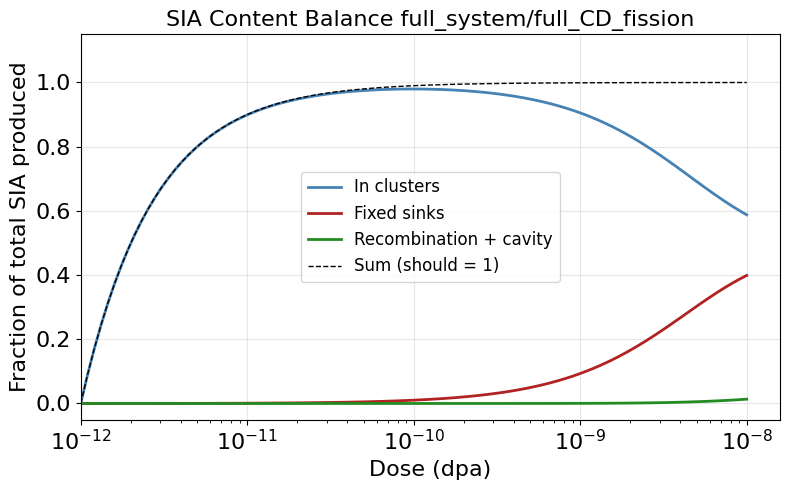

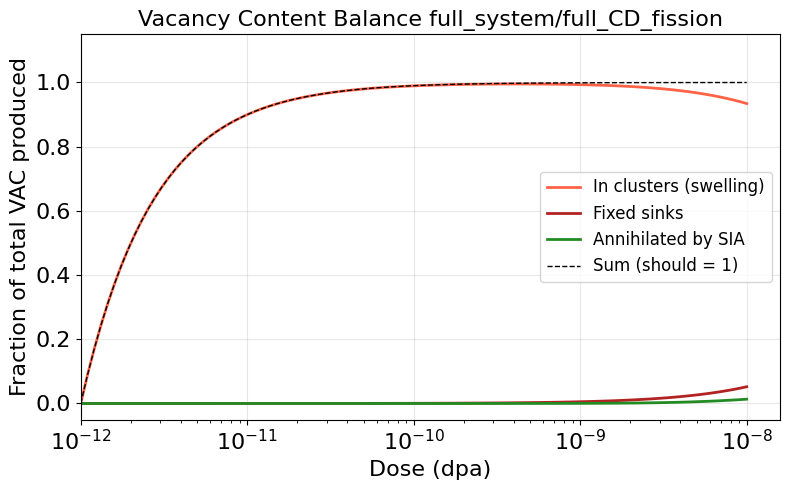

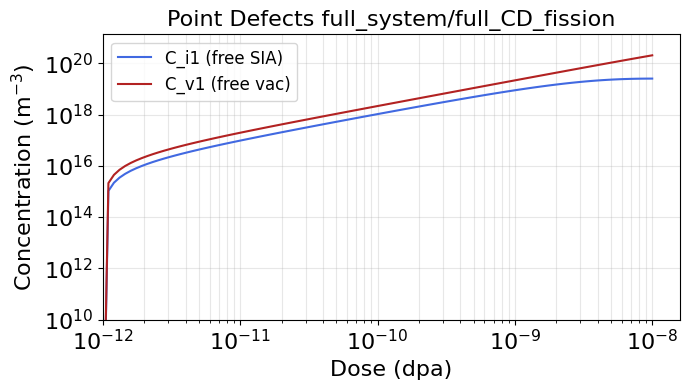

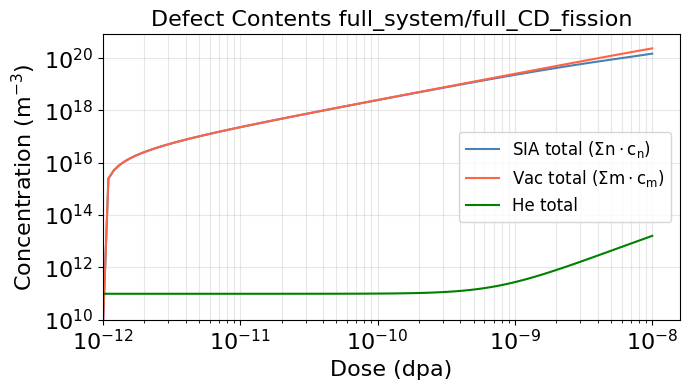

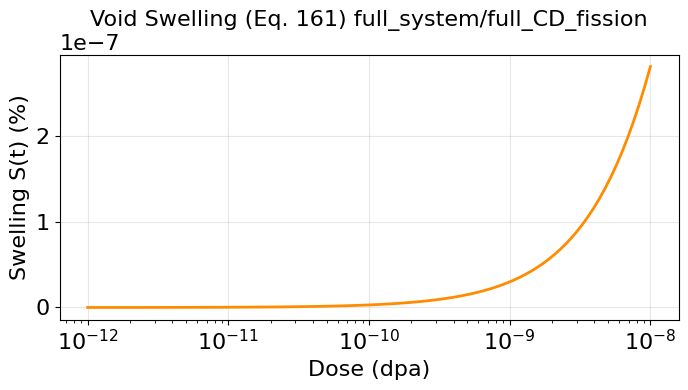

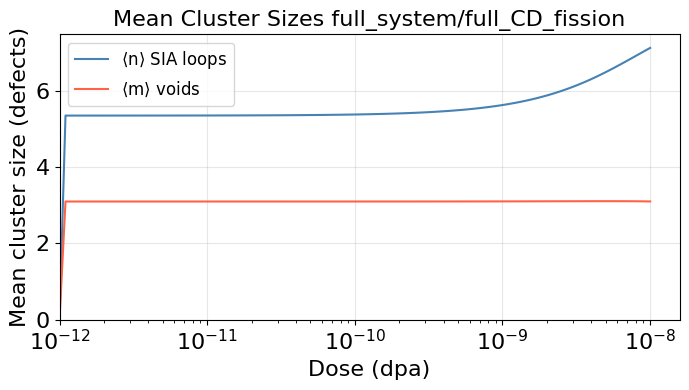

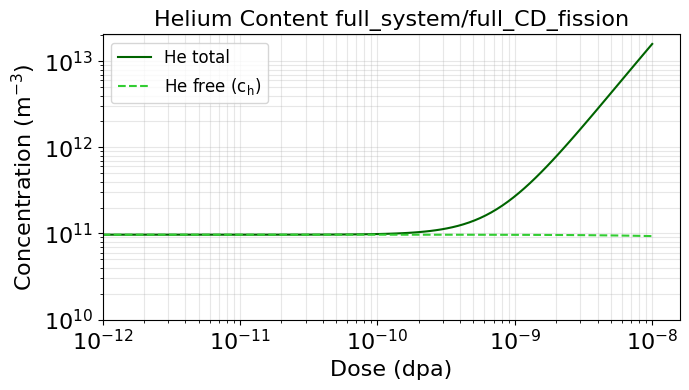

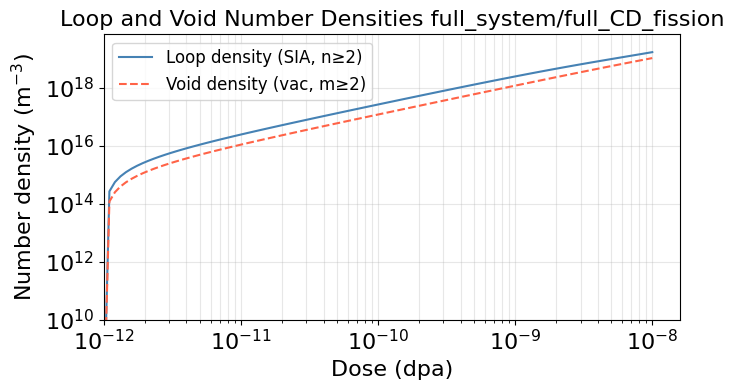

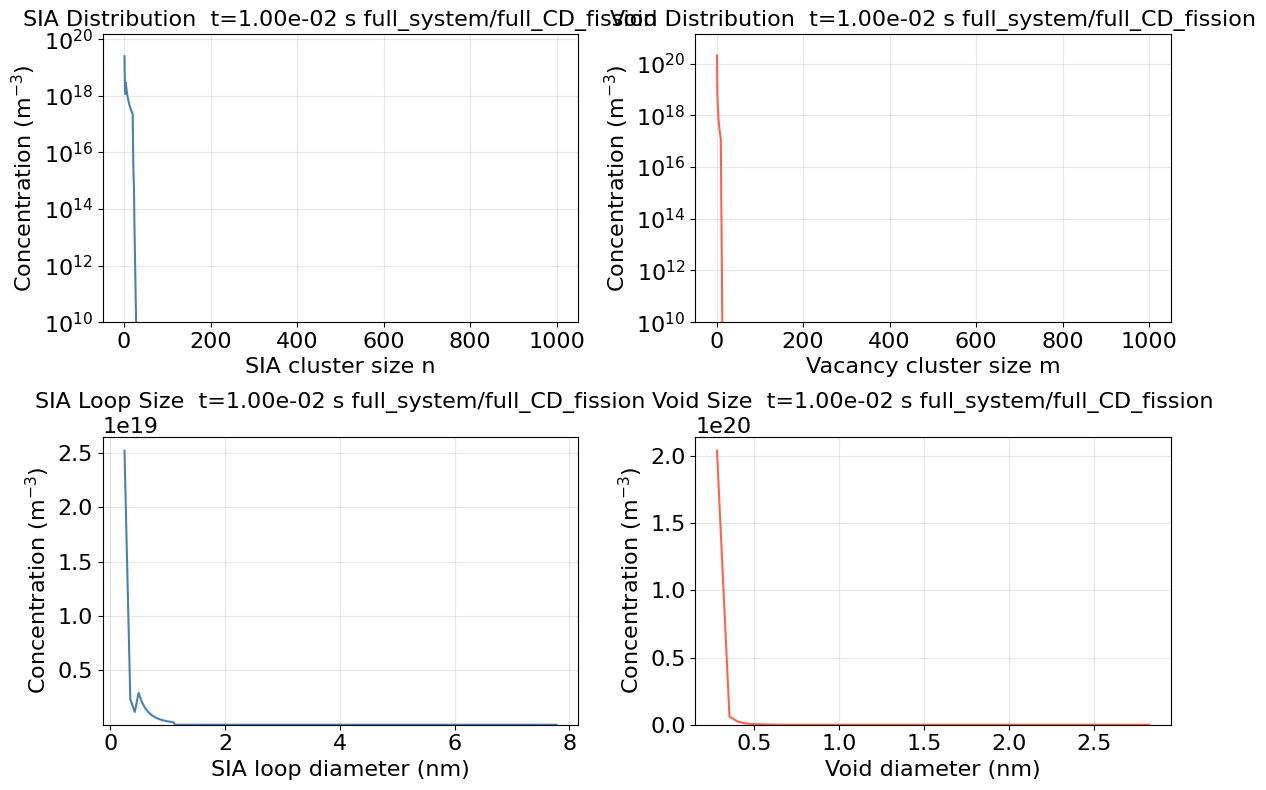

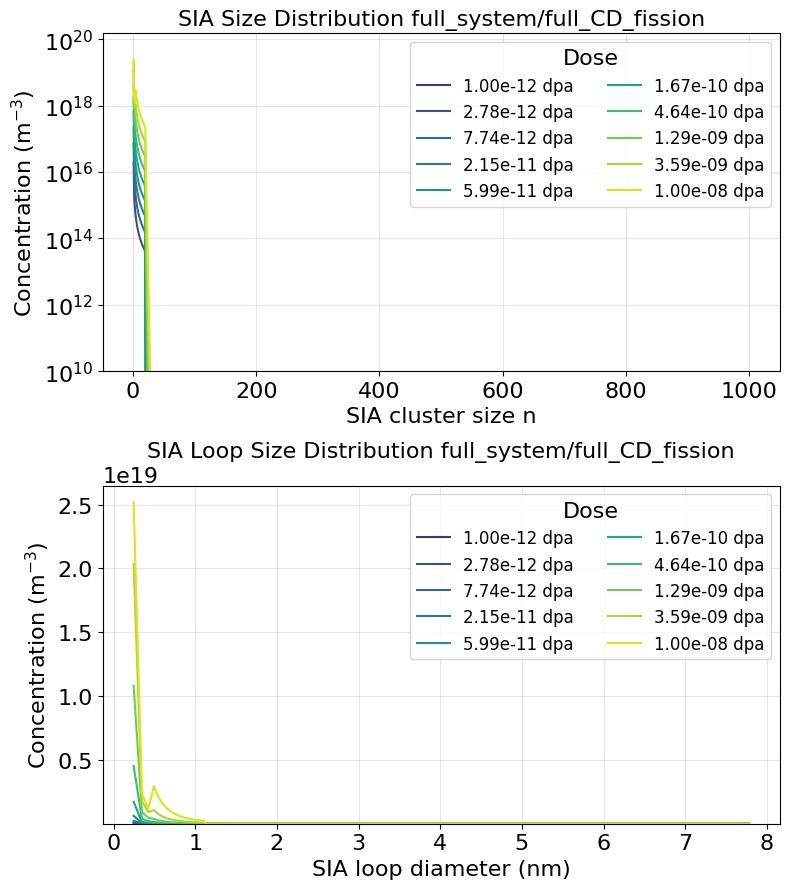

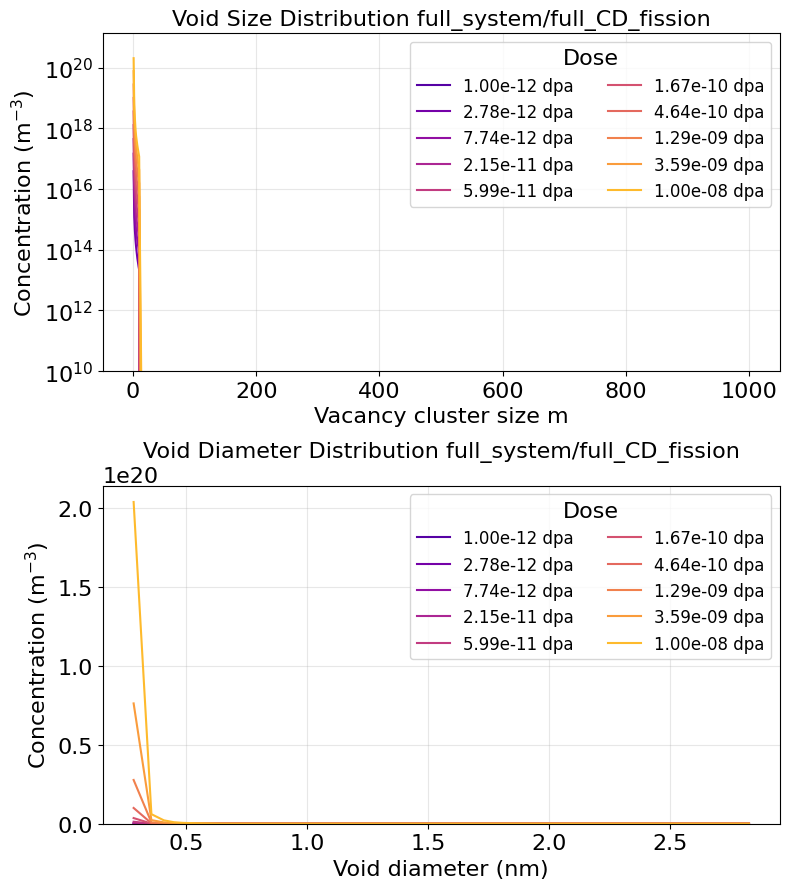

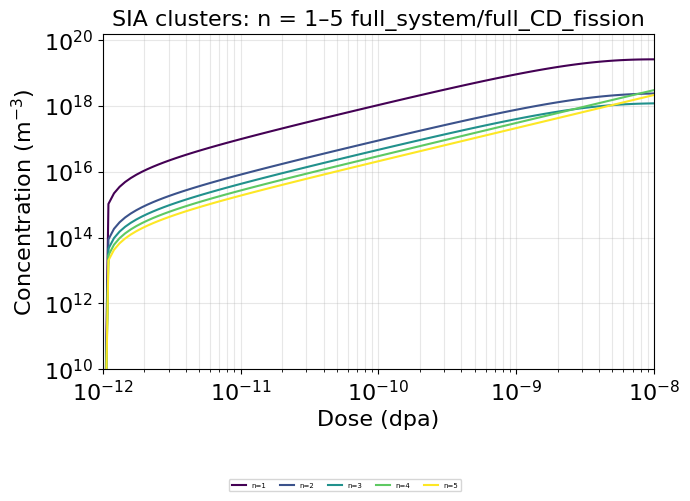

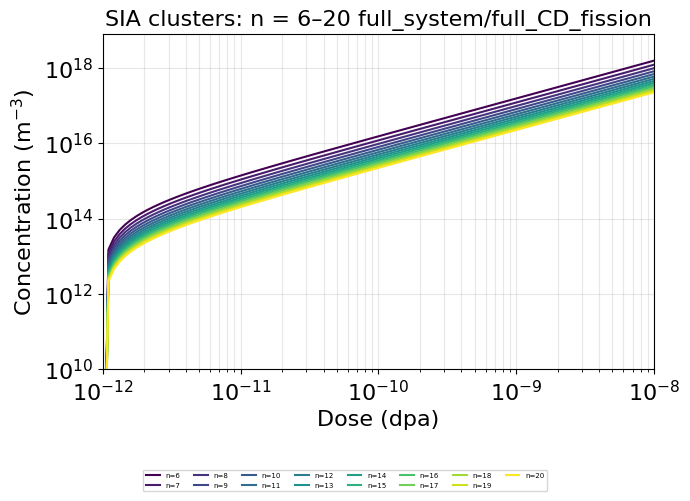

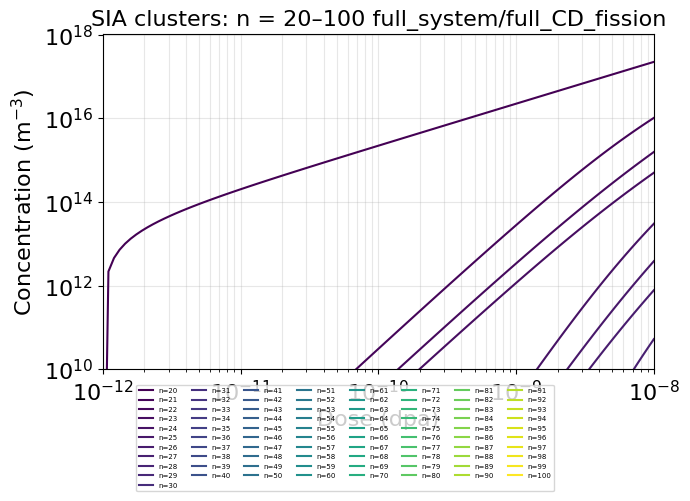

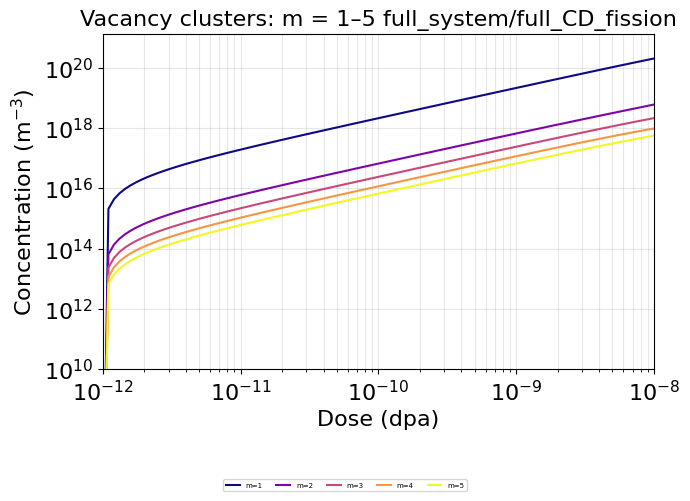

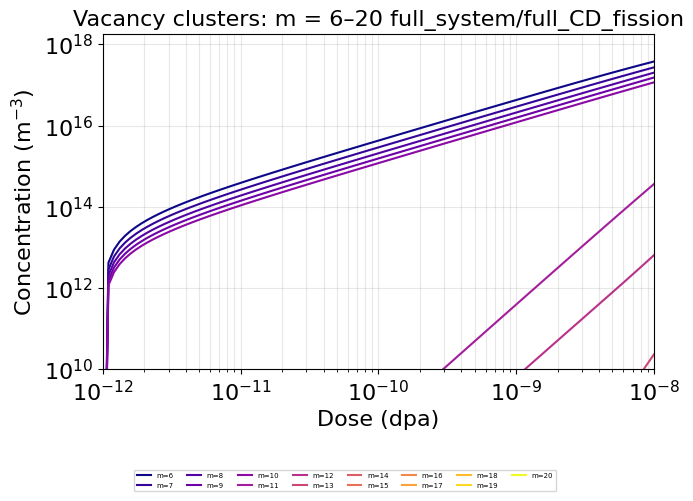

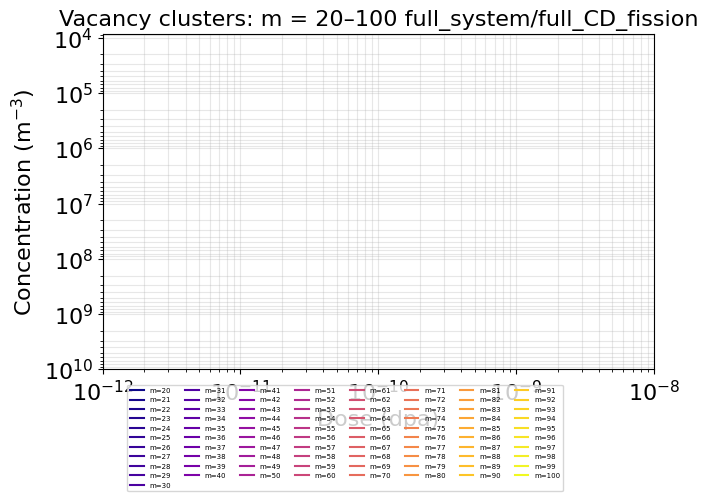

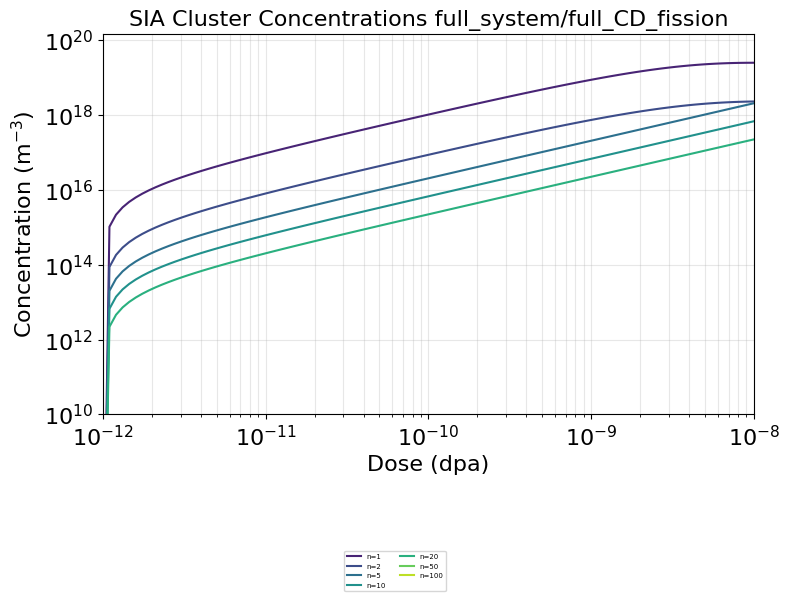

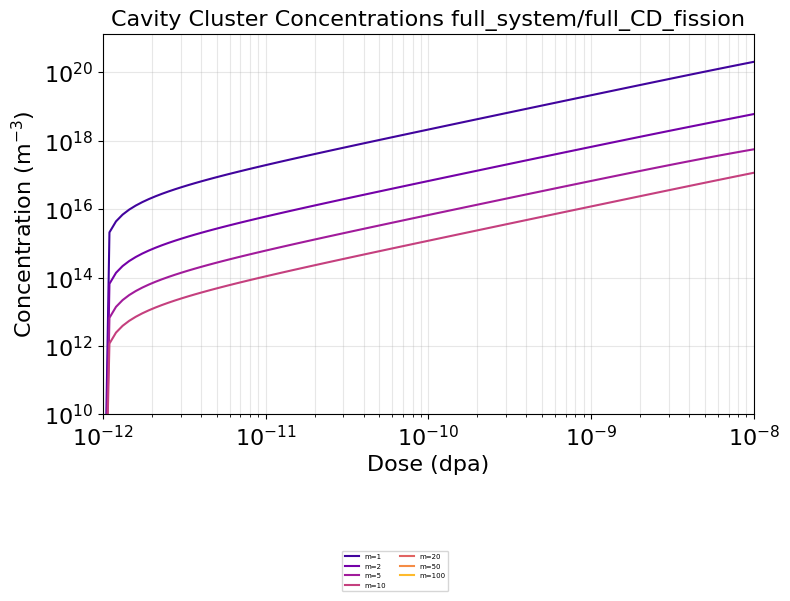

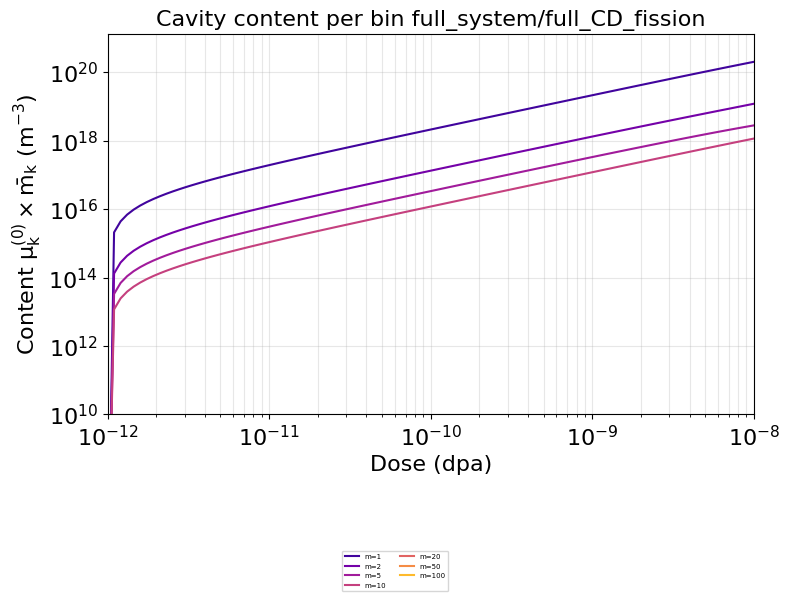

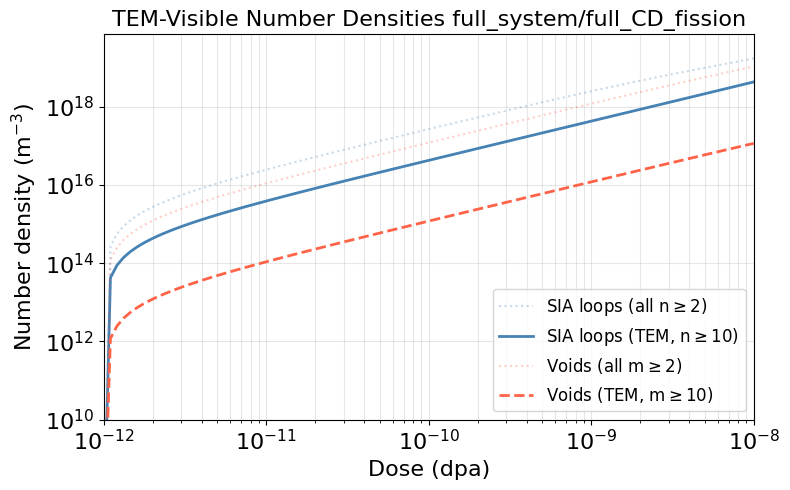

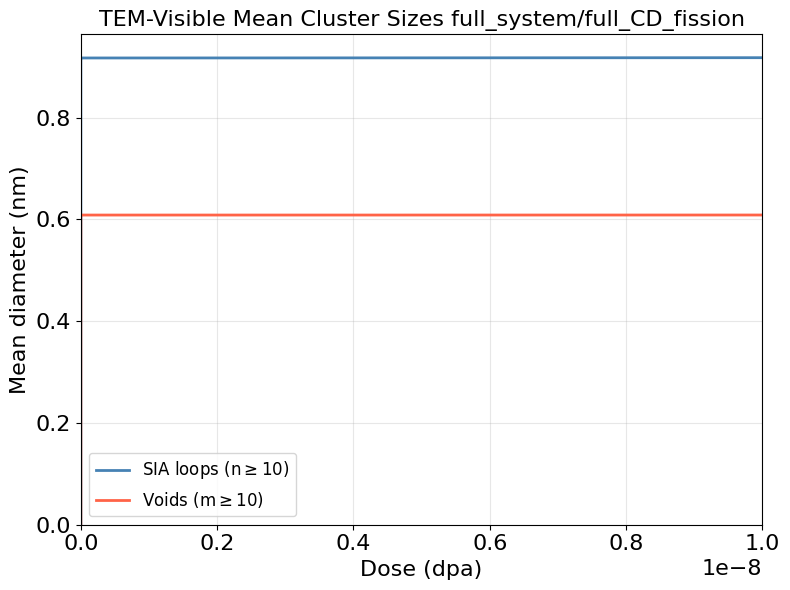

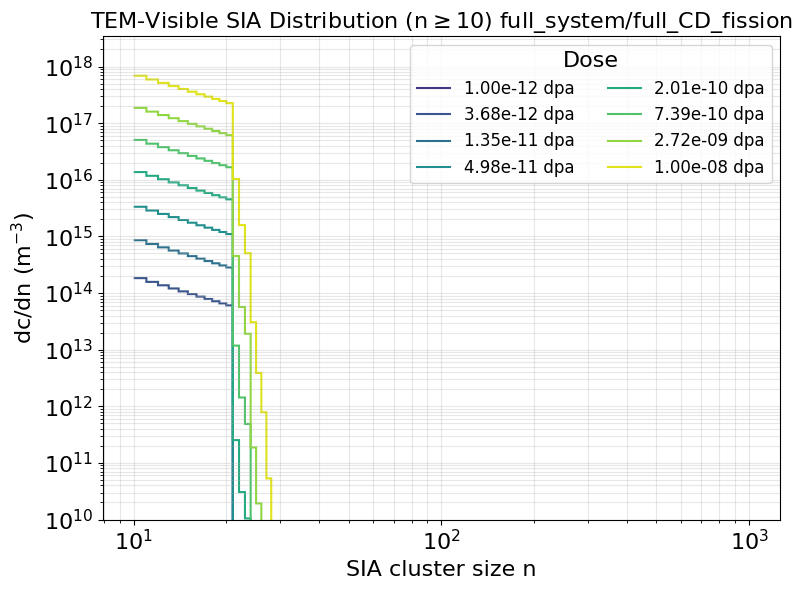

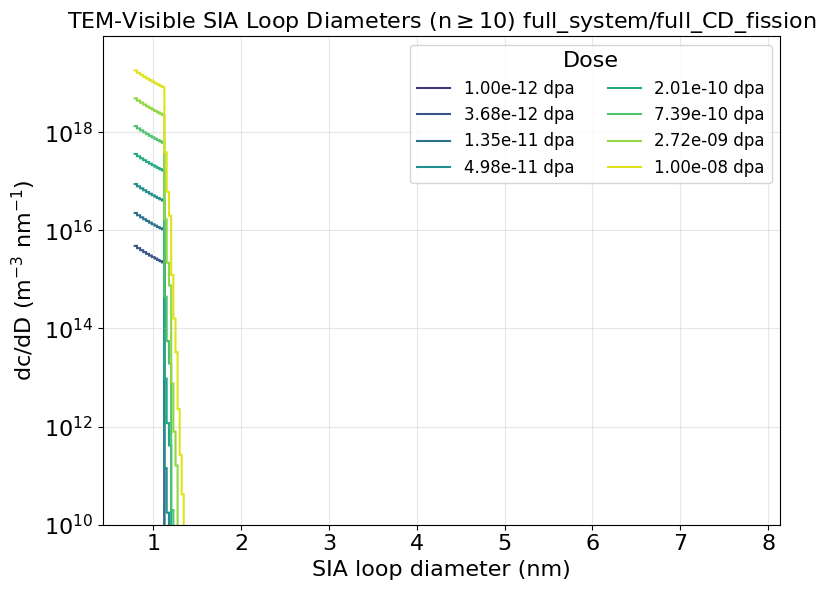

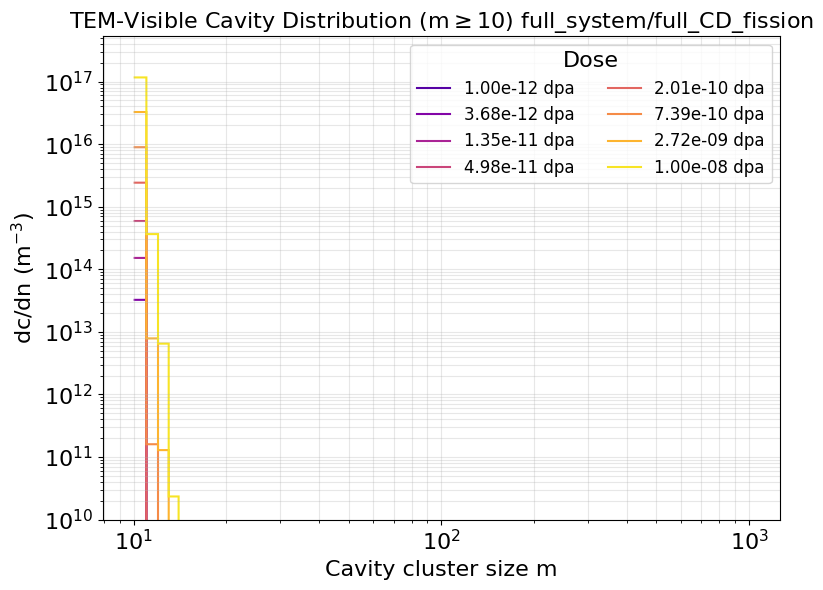

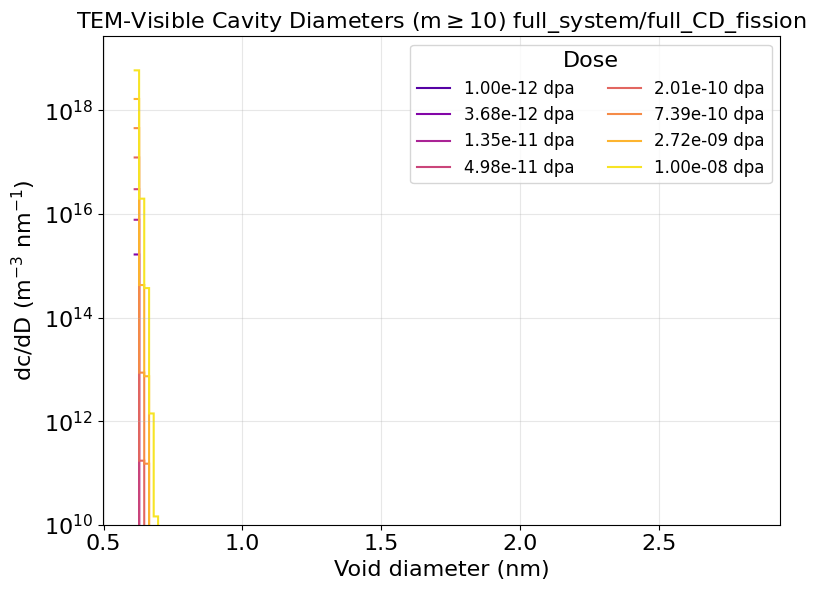

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# ENVIRONMENT SETUP
# ══════════════════════════════════════════════════════════════════════════════
import sys, os, io
# Drop machine-scope OMP_NUM_THREADS so the C++ solver auto-picks threads from N_eq
os.environ.pop('OMP_NUM_THREADS', None)
from pathlib import Path

MODULE_ROOT = Path('../..').resolve()
REPO_ROOT   = MODULE_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import numpy as np
import importlib

# Reload all py_utils modules to pick up code changes
import RadCluster_2_0.py_utils.defect_production as _dp_mod
import RadCluster_2_0.py_utils.binding_energies as _be_mod
import RadCluster_2_0.py_utils.bin_moment_rates as _bmr
import RadCluster_2_0.py_utils.input_data as _inp_mod
import RadCluster_2_0.py_utils.reaction_rates as _rr_mod
import RadCluster_2_0.py_utils.rate_equations as _re_mod
import RadCluster_2_0.py_utils.cpp_bridge as _cb_mod
import RadCluster_2_0.py_utils.post_process as _pp_mod
import RadCluster_2_0.py_utils.simulation as _sim_mod
import RadCluster_2_0.py_utils.visualization as viz
for _m in [_dp_mod, _be_mod, _bmr, _inp_mod, _rr_mod, _re_mod,
           _cb_mod, _pp_mod, _sim_mod, viz]:
    importlib.reload(_m)
from RadCluster_2_0.py_utils.simulation import RadClusterSimulation

# ══════════════════════════════════════════════════════════════════════════════
# 1. Plot axis controls (override viz defaults; None = auto)
# ══════════════════════════════════════════════════════════════════════════════
# Three groups cover the whole plot suite:
#   concentration — concentration vs dose (point defects, totals, He, number
#                    densities, SIA/cavity cluster concentrations).
#   scalar        — scalar metrics vs dose (swelling, mean sizes, fraction
#                    breakdowns, conservation diagnostics).
#   size_dist     — concentration vs cluster size n/m or diameter (nm).
# Set xscale/yscale to 'log' or 'linear' (None = keep each plot's default),
# and xlim/ylim tuples to clip axes (use None on either side for auto).
# legend_fontsize controls the figure-level legends underneath cluster plots.
# ══════════════════════════════════════════════════════════════════════════════
PLOT_CONFIG = {
    'concentration': {
        'xlim':   (None, None),   # (xmin, xmax) in dpa; None = auto
        'ylim':   (1e10, None),   # (ymin, ymax) in m^-3; None = auto
        'xscale': None,           # 'log' | 'linear' | None=keep default
        'yscale': None,
    },
    'scalar': {
        'xlim':   (None, None),
        'ylim':   (None, None),
        'xscale': None,
        'yscale': None,
    },
    'size_dist': {
        'xlim':   (None, None),   # cluster size n/m or diameter (nm)
        'ylim':   (1e10, None),   # concentration in m^-3
        'xscale': None,
        'yscale': None,
    },
    'legend_fontsize': 5,         # font size of legends underneath plots
}
viz.set_plot_config(PLOT_CONFIG)


# ══════════════════════════════════════════════════════════════════════════════
# 2. User selections — material, physics, cluster domain and mobility
# ══════════════════════════════════════════════════════════════════════════════
DEBUG = False
SOLVER_MODE = 'full_system' # "full_system" or "active_window" (auto-serial when threads=1)

# ── Host material (Layer-2 instantiation) ────────────────────────────────────
# 'eurofer97' is the only material currently shipped.  A new host is added by
# declaring its own RAG under py_utils/materials/<name>/ -- see the Material
# options cell below.  The resulting reaction graph is exposed on
# sim.material_rag and sim.state_layout.
MATERIAL = 'eurofer97'

# Two-axis physics selection (combined → physics_option string internally)
EQUATIONS = 'discrete'     # 'discrete' or 'bin_moment'
CASCADE   = 'fission'      # 'fission' or 'fusion'
SHAPE_FUNCTION = 'linear'  # 'lognormal', 'linear', or 'constant' (bin-moment closure)

# ── Domain sizes ─────────────────────────────────────────────────────────────
# SHORT TEST CASE: the validated im5vm2 reference (full per-size discrete,
# fission, I=V=1000) -- a fast (~few-second) smoke test of the two-layer code.
I          = int(1e3)    # max SIA cluster size  (grows adaptively if doublings > 0)
V          = int(1e3)    # max vacancy cluster size

# ── Mobility cutoffs ────────────────────────────────────────────────────────
i_mobile   = 5           # max mobile SIA cluster size
v_mobile   = 2           # max mobile vacancy cluster size

# ── Discrete / binned split ──────────────────────────────────────────────────
# Sizes 1..i_discrete tracked as individual ODEs; beyond that, bin moments.
# For EQUATIONS='discrete', set i_discrete=I, v_discrete=V, I_bin=V_bin=0.
i_discrete = I           # max discrete SIA size  (= I → fully discrete)
v_discrete = V           # max discrete vacancy size (= V → fully discrete)
I_bin      = 0           # SIA bin-moment equations (0 → none, discrete mode)
V_bin      = 0           # VAC bin-moment equations (0 → none, discrete mode)

# ── Other settings ───────────────────────────────────────────────────────────
C_FLOOR    = 1e-25       # concentration floor [atom fraction]
HE_KINETICS = 'quasi_steady_state' # "quasi_steady_state", "dynamic"


# ══════════════════════════════════════════════════════════════════════════════
# 3. Solver configuration
# OpenMP threads: auto-picked by the C++ solver from N_eq when
# OMP_NUM_THREADS is unset (popped above).  Set OMP_NUM_THREADS to override.
# Falls back to a single thread when OpenMP is not available.
# ══════════════════════════════════════════════════════════════════════════════
SOLVER_CONFIG = {
    't_span':   (1e-6, 1e-2),    # SHORT TEST CASE — early-dose smoke test
    'n_points': 100,
    'log_time': True,
    'rtol':     1e-6,
    'atol':     1e-20,
    'timeout_s': 120,   # wall time limit for solver run (seconds)
    'solver_method': {
        'linsol':                 'gmres',  # 'dense', 'band', 'gmres', or 'klu' (sparse direct, full_CD only)
        'preconditioner':        'Woodbury', # 'Jacobi' or 'Woodbury'
        'window_width':          10,
        'concentration_threshold': 1e-22,
        'window_pad':            20,
    }
}


# ══════════════════════════════════════════════════════════════════════════════
# 4. Initialize simulation (reads Excel file; builds the two-layer RAG)
# ══════════════════════════════════════════════════════════════════════════════

_saved_out, _saved_err = sys.stdout, sys.stderr
if not DEBUG:
    sys.stdout = sys.stderr = io.StringIO()
try:
    sim = RadClusterSimulation(
        I=I, V=V,
        solver_mode=SOLVER_MODE,
        equations=EQUATIONS,
        cascade=CASCADE,
        C_floor=C_FLOOR,
        he_kinetics=HE_KINETICS,
        i_mobile=i_mobile,
        v_mobile=v_mobile,
    )
finally:
    sys.stdout, sys.stderr = _saved_out, _saved_err


# ══════════════════════════════════════════════════════════════════════════════
# 4b. Parameter overrides — applied AFTER reading Excel, BEFORE solver run.
#     Keys are the Symbol names from each Excel sheet.
#     Set PARAM_OVERRIDES = {} to use the Excel defaults.
# ══════════════════════════════════════════════════════════════════════════════

PARAM_OVERRIDES = {
    # ── Reactions sheet — irradiation conditions ─────────────────────────
    'T':         673,        # irradiation temperature [K] (im5vm2 baseline)
}

# Inject discrete/bin controls and shape_function into overrides
PARAM_OVERRIDES['i_discrete']     = i_discrete
PARAM_OVERRIDES['v_discrete']     = v_discrete
PARAM_OVERRIDES['shape_function'] = SHAPE_FUNCTION
if I_bin is not None:
    PARAM_OVERRIDES['I_bin'] = I_bin
if V_bin is not None:
    PARAM_OVERRIDES['V_bin'] = V_bin

if PARAM_OVERRIDES:
    _saved_out2, _saved_err2 = sys.stdout, sys.stderr
    if not DEBUG:
        sys.stdout = sys.stderr = io.StringIO()
    try:
        inp = sim.input_data
        for key, val in PARAM_OVERRIDES.items():
            placed = False
            for d in [inp.production_fission, inp.production_fusion,
                      inp.diffusion, inp.reactions,
                      inp.energetics, inp.dissociation]:
                if key in d:
                    d[key] = val
                    placed = True
            if not placed:
                inp.reactions[key] = val
        # Mobility cutoffs need to land in `diffusion` (where _calculate_derived
        # reads them) AND in `reactions` (provenance), with int cast.
        for mob_key in ('i_mobile', 'v_mobile'):
            if mob_key in PARAM_OVERRIDES:
                v = int(PARAM_OVERRIDES[mob_key])
                inp.diffusion[mob_key] = v
                inp.reactions[mob_key] = v
        inp._calculate_derived()
        sim.rebuild_rates()
    finally:
        sys.stdout, sys.stderr = _saved_out2, _saved_err2

    print(f'Applied {len(PARAM_OVERRIDES)} parameter overrides:')
    for k, v in PARAM_OVERRIDES.items():
        print(f'  {k:>12} = {v}')
else:
    print('Using Excel defaults (no overrides)')

# ── Report system size ────────────────────────────────────────────────────
re = sim.rate_equations
if hasattr(re, 'I_bin'):
    P = re.n_mom
    print(f'\nHybrid discrete + bin-moment system (shape_function={re.shape_function!r}):')
    print(f'  Discrete SIA:  i = 1..{re.i_discrete}  ({re.i_discrete} ODEs)')
    print(f'  Binned SIA:    I_bin = {re.I_bin}  ({P} moments each = {P*re.I_bin} ODEs)')
    print(f'  Discrete VAC:  v = 1..{re.v_discrete}  ({re.v_discrete} ODEs)')
    print(f'  Binned VAC:    V_bin = {re.V_bin}  ({P} moments each = {P*re.V_bin} ODEs)')
    he_odes = re.N_eq - (re.i_discrete + P*re.I_bin + re.v_discrete + P*re.V_bin)
    print(f'  He state:      {he_odes} ODE(s)')
    print(f'  ──────────────────────')
    print(f'  Total N_eq = {re.N_eq}  (full_CD would be {sim.input_data.I + sim.input_data.V + 2})')
else:
    print(f'\nFull per-size system: N_eq = {re.N_eq}')


# ══════════════════════════════════════════════════════════════════════════════
# 5. Build live progress callback
# ══════════════════════════════════════════════════════════════════════════════
sim._progress_rows = []

rr      = sim.reaction_rates
rate_eq = sim.rate_equations
G_dpa   = sim.input_data.derived['G']
Omega   = sim.input_data.derived['Omega']
s2m     = 1.0 / Omega

_row_idx = [0]

def _progress_callback(row):
    sim._progress_rows.append(dict(row))
    j   = _row_idx[0];  _row_idx[0] += 1
    t_  = row.get('t', 0.0)
    dos = t_ * G_dpa
    if DEBUG:
        ci1 = row.get('c_i1', 0.0)
        cv1 = row.get('c_v1', 0.0)
        sys.stderr.write(
            f'  [{j:>4d}] t={t_:.4e}  dose={dos:.3e}'
            f'  Ci1={ci1*s2m:.3e}  Cv1={cv1*s2m:.3e} m^-3\n')
        sys.stderr.flush()


# ══════════════════════════════════════════════════════════════════════════════
# 6. Run simulation
#    sim.run() integrates the fixed domain once.  For long, high-dose runs
#    use sim.run_adaptive() instead — it integrates in short segments and
#    doubles I / V on the fly when the size distribution reaches the
#    boundary (no restart from t=0).
#
#    Graceful interrupt: press Ctrl+C (or Jupyter "Interrupt Kernel") at
#    any time.  The C++ subprocess is terminated, completed segments are
#    kept, and results / plots are saved for the last integration point.
# ══════════════════════════════════════════════════════════════════════════════
%matplotlib inline

# results = sim.run_adaptive(
results = sim.run(
    solver_config=SOLVER_CONFIG,
    save_output=False,           # defer saving — we handle it below
    progress_callback=_progress_callback,
#     boundary_threshold=0.05,      # adapt if >5% of content at boundary
#     max_doublings=8,             # 0 = no adaptive doubling
#     points_per_segment=50,       # check every 50 output points
)

# ── Recovery cascade: try every place the partial results may have landed ───
if results is None:
    results = getattr(sim, '_accumulated_results', None)
    if results is not None:
        print('  Recovered partial results from sim._accumulated_results')
if results is None:
    results = getattr(sim, '_partial_results', None)
    if results is not None:
        print('  Recovered partial results from sim._partial_results')

if results is None:
    print('Simulation produced no results — nothing to save.')
else:
    # ── SAVE FIRST, print summary AFTER, so a print failure on degenerate
    # partial data cannot prevent the save. ─────────────────────────────────
    try:
        sim._diag_text = sim.reaction_rates.format_diagnostic(
            mean_n_i=(results['mean_n_i'][-1]
                      if len(results.get('mean_n_i', [])) > 0 else None))
    except Exception as exc:
        print(f'  diag_text build failed ({type(exc).__name__}: {exc})')
        sim._diag_text = ''
    try:
        sim._save_output(results, SOLVER_CONFIG)
    except Exception as exc:
        import traceback
        print(f'  _save_output raised {type(exc).__name__}: {exc}')
        traceback.print_exc()

    # Now the summary prints — each one guarded so a missing key cannot
    # mask failures elsewhere.
    def _safe(label, key, fmt='{:.4e}', mul=1.0):
        arr = results.get(key)
        if arr is None or len(arr) == 0:
            print(f'{label}: <unavailable>')
        else:
            try:
                print(f'{label}: ' + fmt.format(float(arr[-1]) * mul))
            except Exception as exc:
                print(f'{label}: <{type(exc).__name__}>')

    t_arr = results.get('t', [])
    print(f'\nFinal domain: I={sim.input_data.I}  V={sim.input_data.V}')
    if len(t_arr) > 0:
        print(f'Solution:         {len(t_arr)} time points, '
              f't = [{t_arr[0]:.2e}, {t_arr[-1]:.2e}] s')
    _safe('Final dose      ', 'dose')
    _safe('Swelling (final)', 'swelling', '{:.6f} %', 100.0)
    _safe('C_He_tot (final)', 'C_He_tot', '{:.3e}')
    _safe('mean_n_i (final)', 'mean_n_i', '{:.2f}')
    _safe('mean_n_v (final)', 'mean_n_v', '{:.2f}')
    _safe('N_loops  (final)', 'N_loops',  '{:.3e}')
    _safe('N_voids  (final)', 'N_voids',  '{:.3e}')
    _safe('delta_FP (final)', 'delta_FP', '{:.3e}  (Eq. 96)')
    _safe('delta_He (final)', 'delta_He', '{:.3e}  (Eq. 97)')

## Material options — populations, edges, and the reaction graph

The host material (**Layer 2**) declares the *Reaction Admissibility Graph* (RAG) that the abstract core (**Layer 1**) integrates. The cell below inspects the live two-layer description carried on `sim.material_rag` / `sim.state_layout`:

- **`MATERIAL`** selects the host instantiation (set above; `'eurofer97'` is the only one shipped).
- **Populations** — the distinct defect phases (one SIA `bulk`, one vacancy `bulk` for EUROFER-97).
- **Edges** — every admissible elementary reaction, tagged with one of the ten `EdgeClass` values (P1–P8 + coalescence/annihilation/source).
- **State layout** — how the RAG vertices map onto the flat ODE state vector.

This makes the model self-describing: the graph *is* the physics that was selected.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# MATERIAL OPTIONS — populations, edges, and the reaction admissibility graph
# ══════════════════════════════════════════════════════════════════════════════
# The host material (Layer 2) DECLARES the Reaction Admissibility Graph (RAG)
# that the abstract core (Layer 1) integrates.  `sim.material_rag` is that
# graph; `sim.state_layout` is its vertex -> ODE-index map.  Inspect — and,
# by editing MATERIAL / the physics axes above, select — the model here.
#
# The RAG below IS the model definition: every admissible elementary reaction
# is one edge, tagged with one of the ten EdgeClass values.  To add a new
# host material, declare its own RAG under py_utils/materials/<name>/ — the
# abstract core, solver, preconditioner and reductions are reused unchanged.
# ══════════════════════════════════════════════════════════════════════════════
from RadCluster_2_0.py_utils.core import EdgeClass

rag    = getattr(sim, 'material_rag', None)
layout = getattr(sim, 'state_layout', None)

print(f'Host material : {MATERIAL!r}')
print(f'Physics       : equations={EQUATIONS!r}  cascade={CASCADE!r}  '
      f'he_kinetics={HE_KINETICS!r}')

if rag is None:
    print('\nMaterial RAG unavailable — RadClusterSimulation did not build a '
          'two-layer description for this configuration.')
else:
    print(f'\n{rag.summary()}')

    # ── Populations — the defect phases tracked ──────────────────────────
    print('\nPopulations (defect phases, one size axis each):')
    print(f"  {'polarity':9s} {'name':14s} {'n_min':>6s} {'mobile_max':>11s}")
    for p in rag.populations:
        print(f'  {p.polarity.label:9s} {p.name:14s} '
              f'{p.n_min:6d} {p.mobile_max:11d}')
    print('  (next planned: the <111> / <100> SIA loop split — paper Eq. 12)')

    # ── Admissible reaction edges, grouped by edge class ─────────────────
    print('\nAdmissible reaction edges (by edge class):')
    for ec in EdgeClass:
        edges = rag.edges_of_class(ec)
        if edges:
            labels = ', '.join(e.label for e in edges)
            print(f'  {ec.value:16s} x{len(edges)}  ->  {labels}')

    # ── State-vector layout — RAG vertices mapped to ODE indices ─────────
    if layout is not None:
        print()
        print(layout.describe())


Host material : 'eurofer97'
Physics       : equations='discrete'  cascade='fission'  he_kinetics='quasi_steady_state'

RAG 'EUROFER-97': 2 populations, 16 edges, 16 kernels; edge classes active: {'growth': 3, 'shrinkage': 2, 'dissociation': 2, 'recombination': 1, 'annihilation': 1, 'solute_trapping': 1, 'coalescence': 2, 'source': 2, 'sink': 2}

Populations (defect phases, one size axis each):
  polarity  name            n_min  mobile_max
  sia       bulk                1           5
  vacancy   bulk                1           2
  (next planned: the <111> / <100> SIA loop split — paper Eq. 12)

Admissible reaction edges (by edge class):
  growth           x3  ->  P2v_cavity_growth, P3_loop_growth, P7_trap_mutation
  shrinkage        x2  ->  P2i_cavity_shrink, P3_loop_shrink
  dissociation     x2  ->  P5i_SIA_emission, P5v_VAC_emission
  recombination    x1  ->  P1_recombination
  annihilation     x1  ->  VI_annihilation
  solute_trapping  x1  ->  P8_radiation_resolution
  coalescence  

Loading plot data: D:\GitHub\RadCluster\RadCluster_2_0\output\20260522_031533_full_system_full_CD_fission_I1000V1000_im5vm2\plots\plot_data.pkl


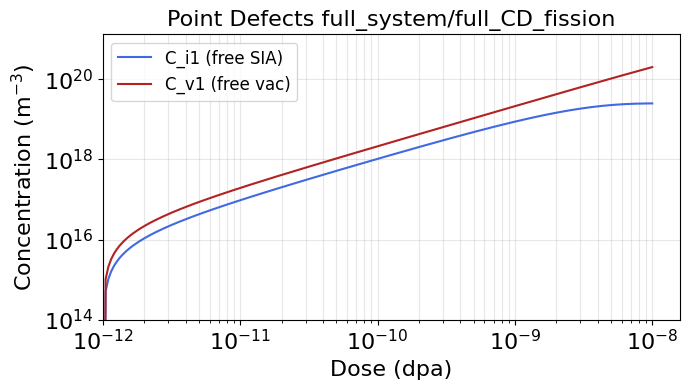

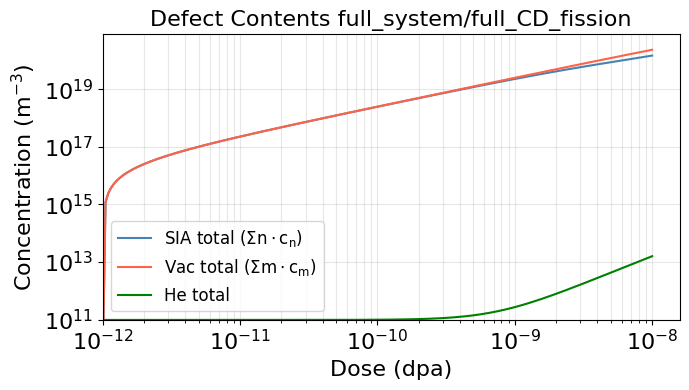

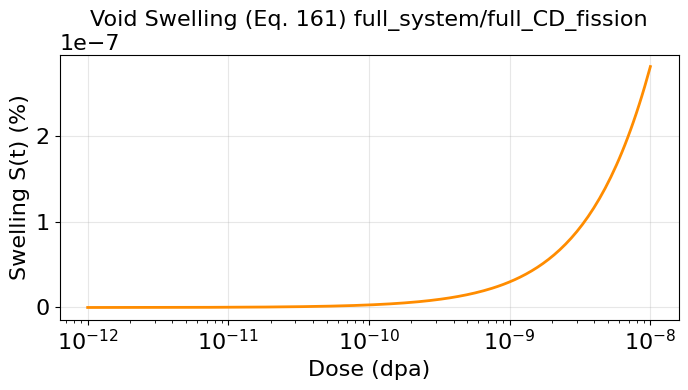

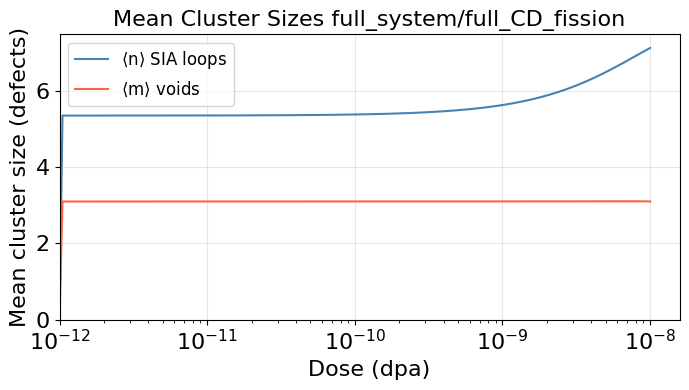

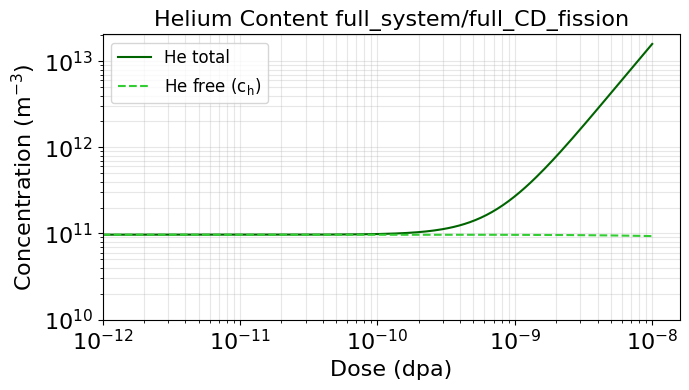

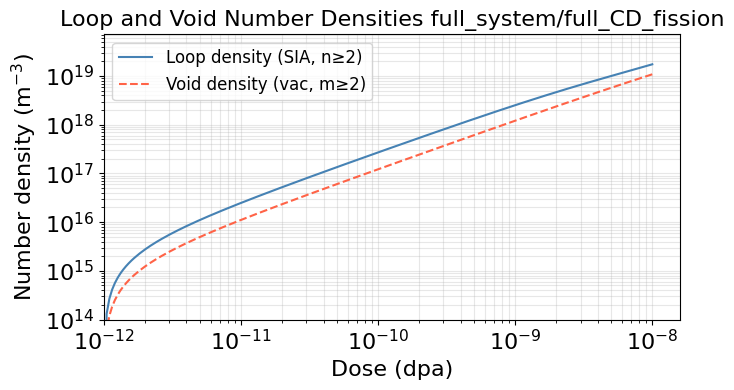

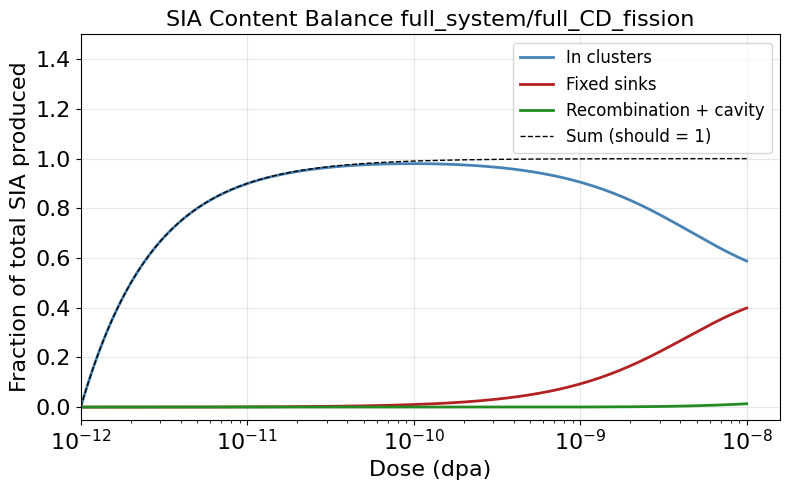

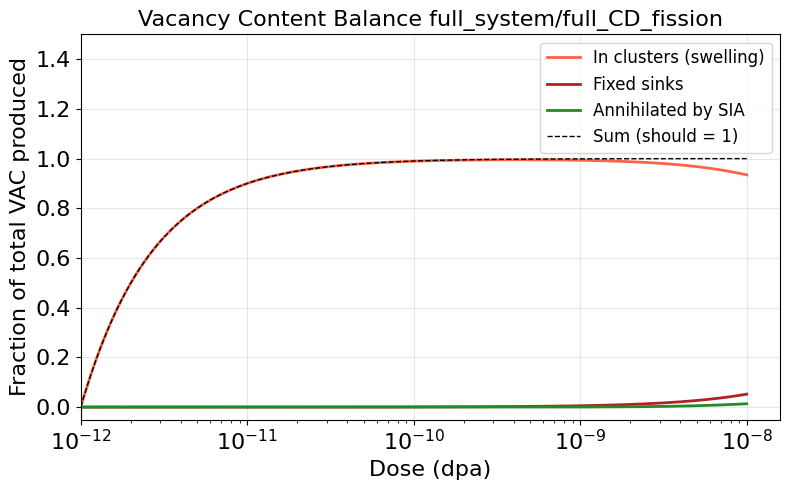

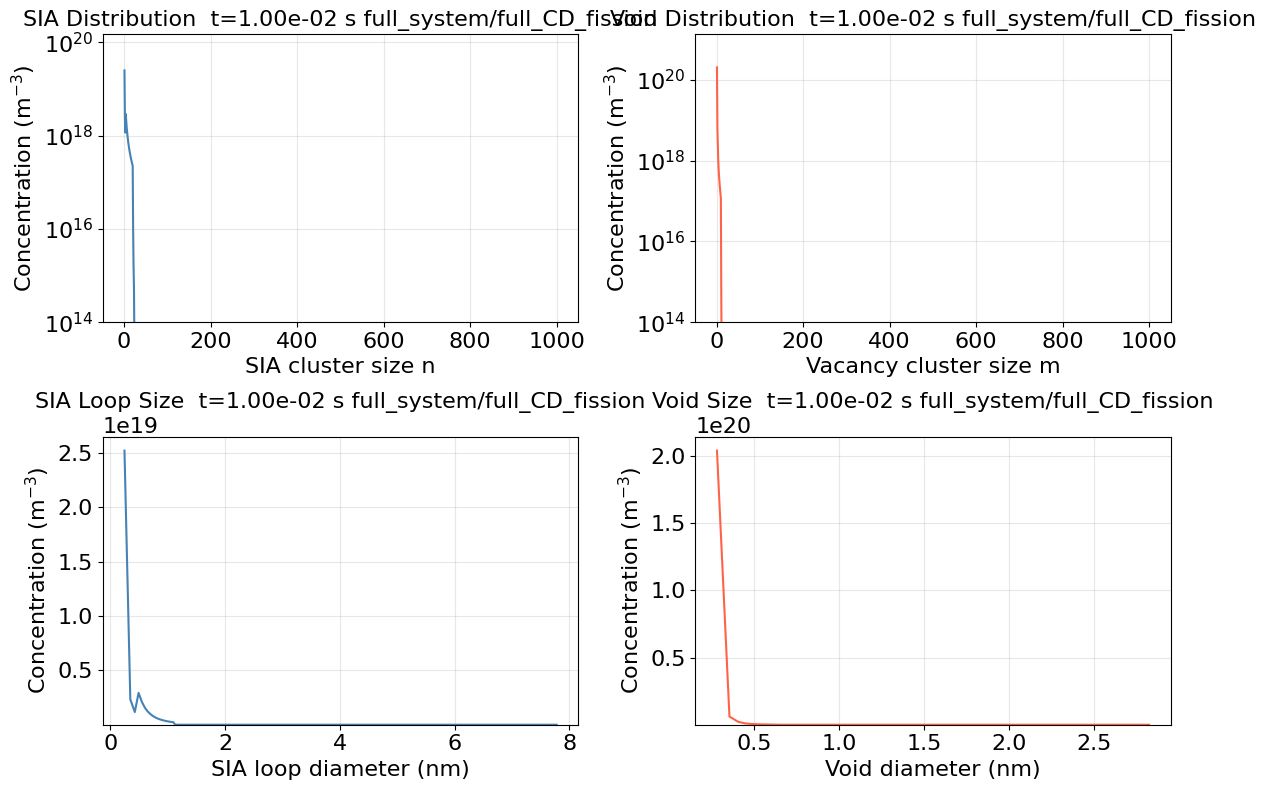

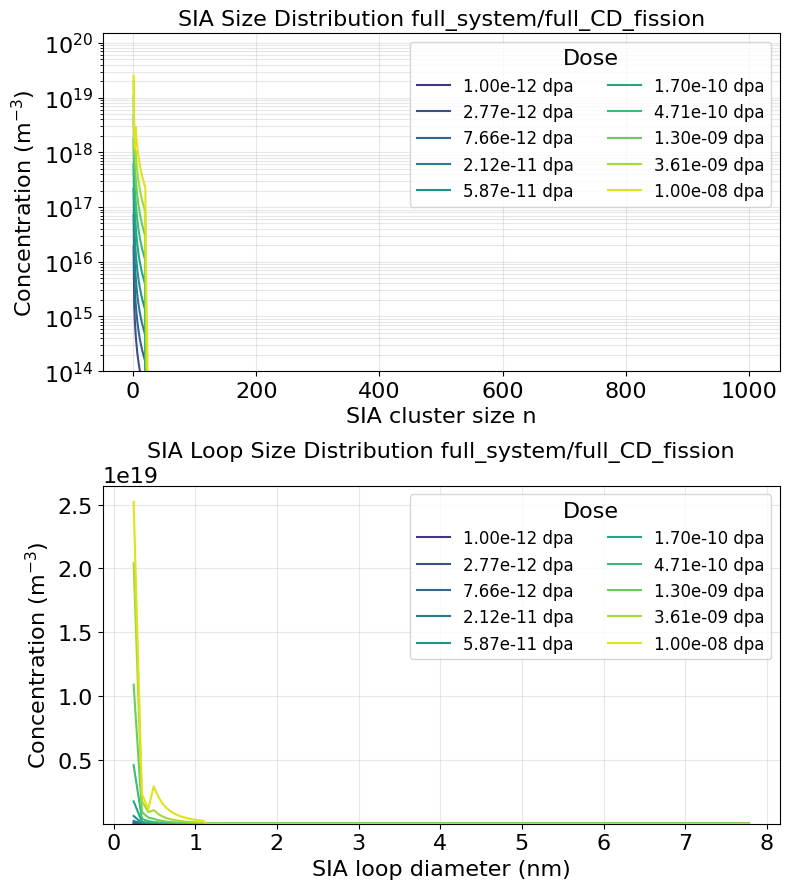

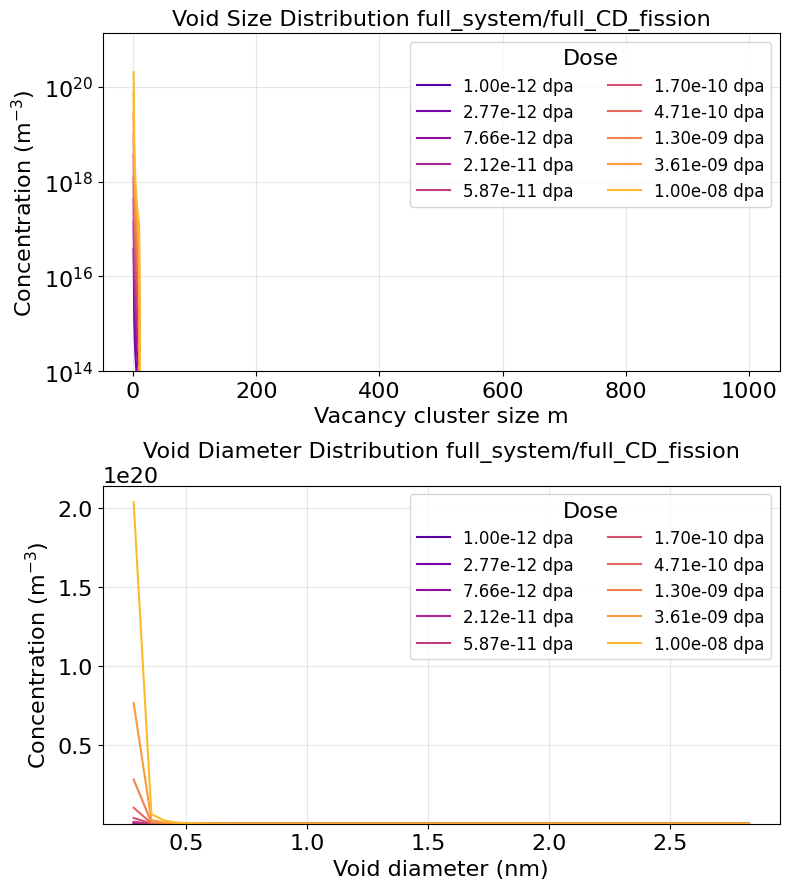

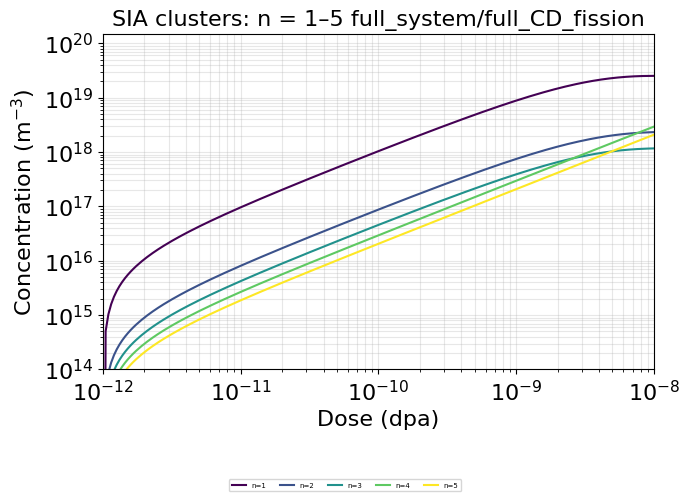

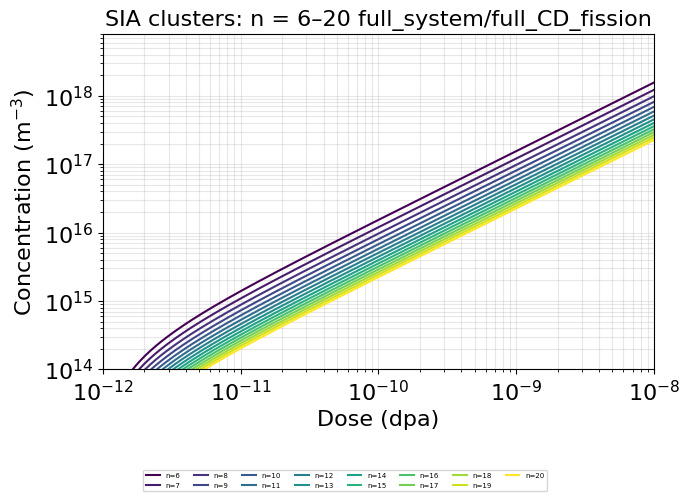

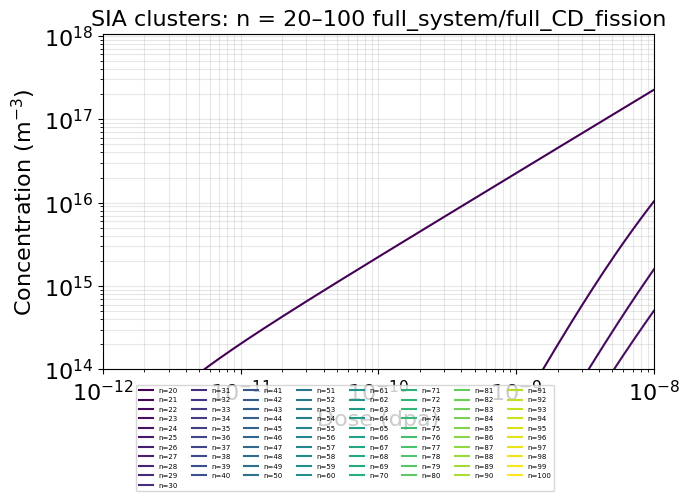

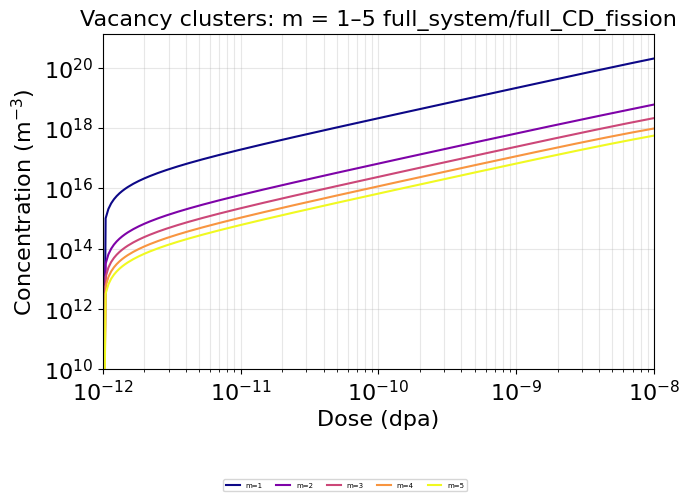

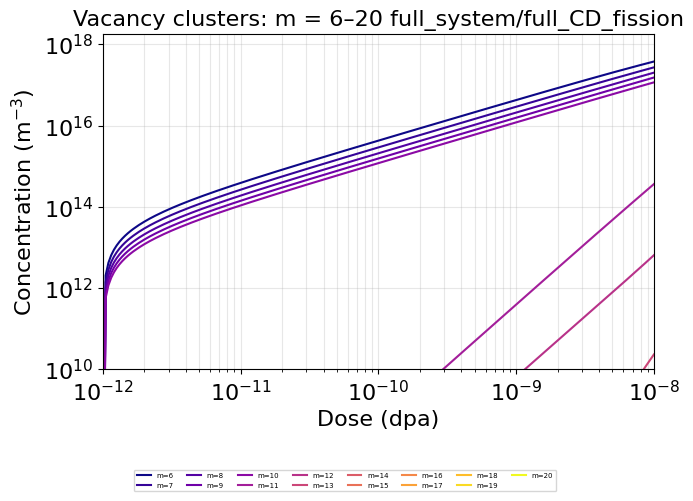

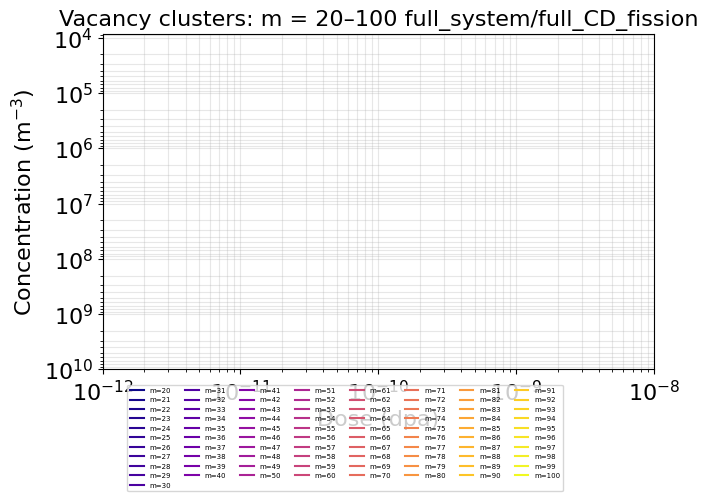

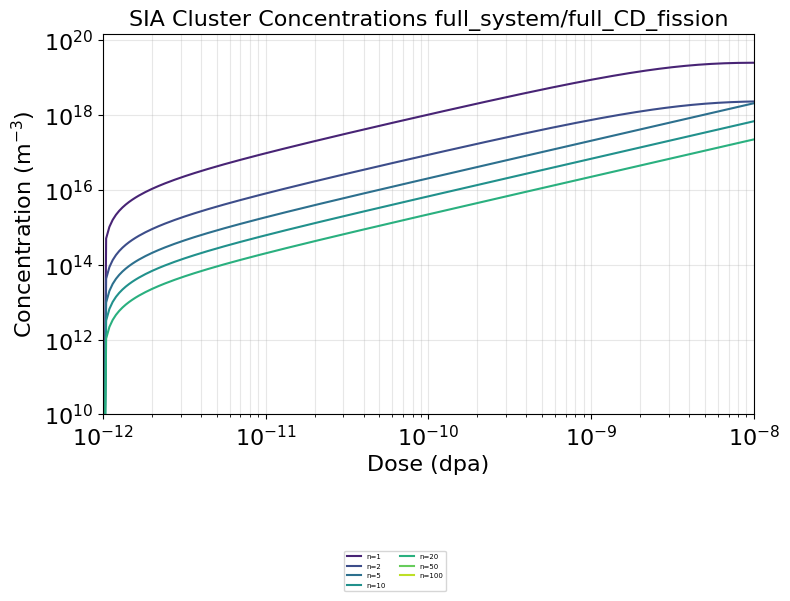

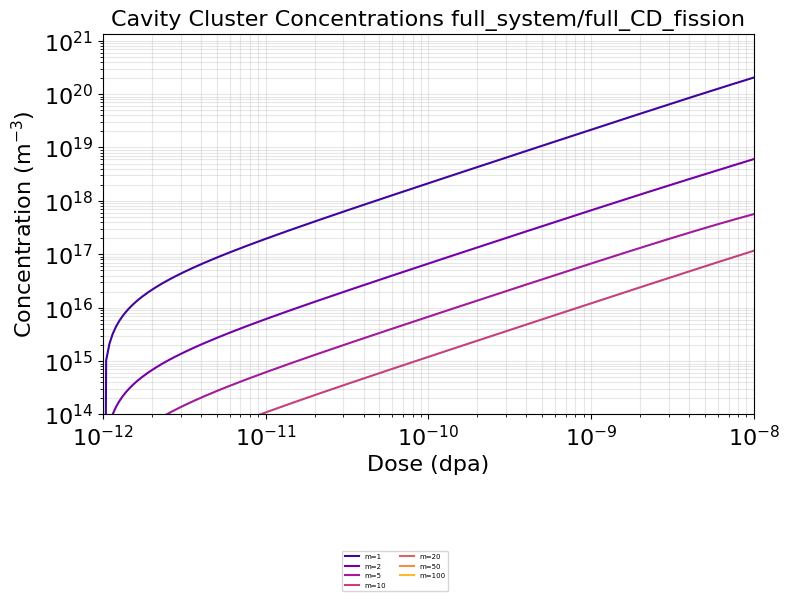

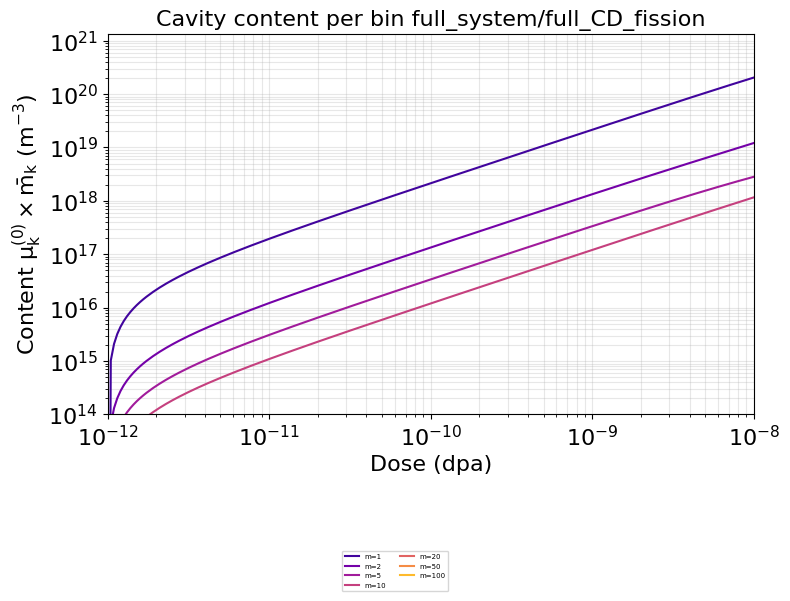

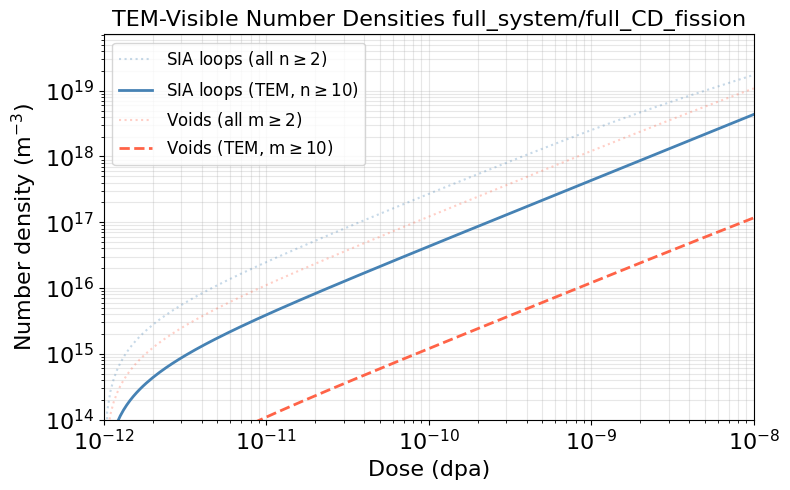

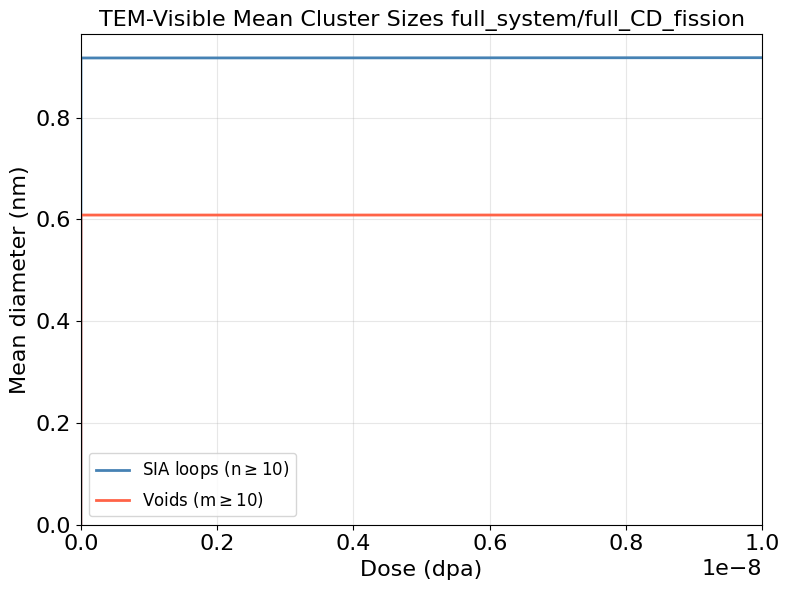

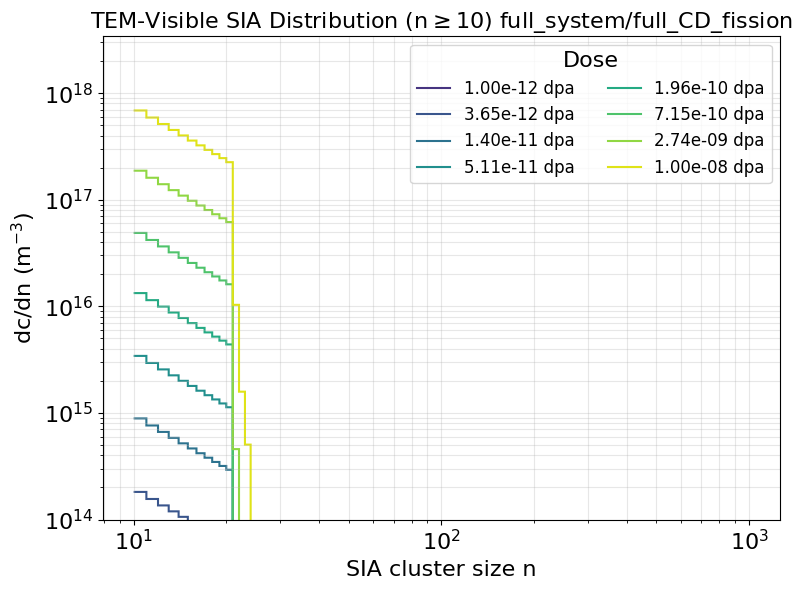

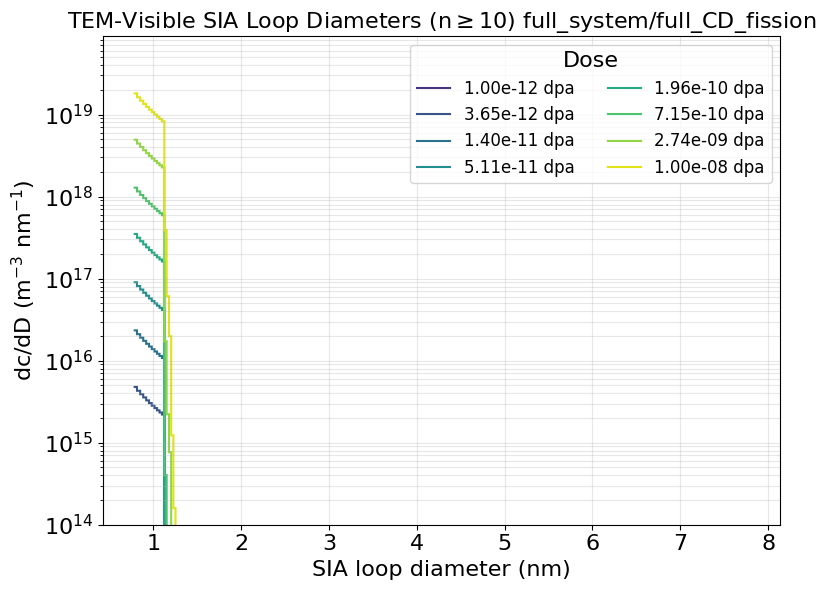

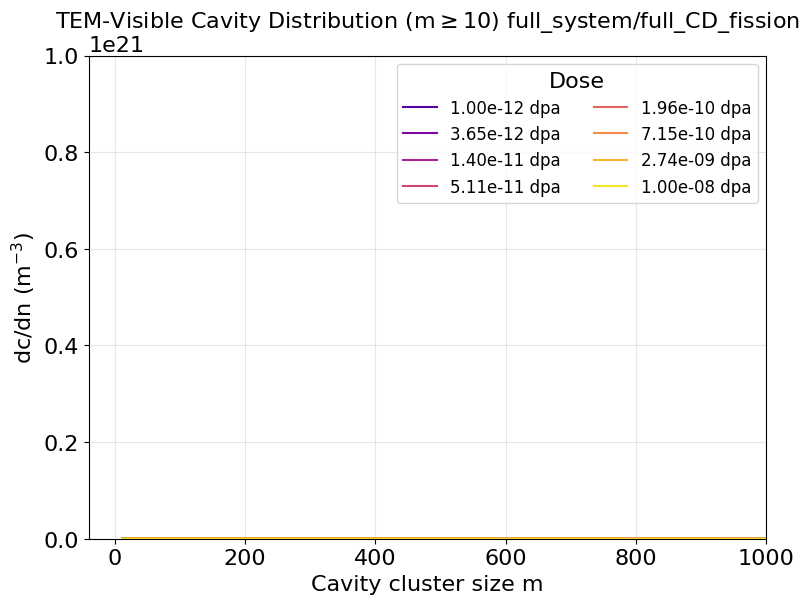

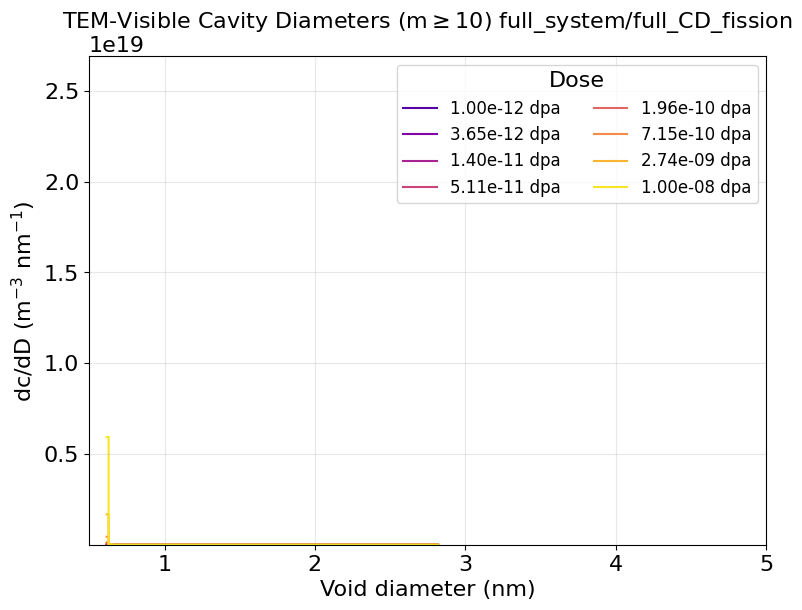

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# REPLOT FROM SAVED DATA — adjust axes without re-running the simulation
# ══════════════════════════════════════════════════════════════════════════════
# This cell reads `plot_data.pkl` (auto-saved by `save_all_plots` next to the
# PNGs) and re-renders every figure with user-controlled axis limits/scales.
# Edit the kwargs in each section and re-run only this cell — no solver call.
#
# Pin a specific run by setting PLOT_DATA_PATH to its absolute path; leave
# None to auto-pick the most-recent output directory.
# ══════════════════════════════════════════════════════════════════════════════
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

PLOT_DATA_PATH = None   # str or Path; None = auto-pick latest

if PLOT_DATA_PATH is None:
    output_root = MODULE_ROOT / 'output'
    candidates = sorted(output_root.glob('*/plots/plot_data.pkl'))
    if not candidates:
        raise FileNotFoundError(f'No plot_data.pkl found under {output_root}')
    PLOT_DATA_PATH = candidates[-1]

print(f'Loading plot data: {PLOT_DATA_PATH}')
_pd = viz.load_plot_data(PLOT_DATA_PATH)
results     = _pd['results']
input_data  = _pd['input_data']
rate_eq_obj = _pd['rate_eq_obj']
label       = _pd.get('label', '')


def _replot(plot_fn, *args, xlim=(None, None), ylim=(None, None),
            xscale=None, yscale=None, **kwargs):
    """Call a plot function, then override every axis's limits/scales.

    Robust to plot functions that return a single Figure, a list/tuple of
    Figures, or None; a plot function that raises is reported and skipped
    so one bad figure cannot abort the whole replot cell.
    """
    try:
        out = plot_fn(*args, title=label, **kwargs)
    except Exception as exc:                       # noqa: BLE001
        print(f'  {plot_fn.__name__}: skipped ({type(exc).__name__}: {exc})')
        return None
    if out is None:
        print(f'  {plot_fn.__name__}: skipped (no data for this run)')
        return None
    figs = list(out) if isinstance(out, (list, tuple)) else [out]
    for fig in figs:
        if fig is None or not hasattr(fig, 'axes'):
            continue
        for ax in fig.axes:
            if xscale is not None:
                ax.set_xscale(xscale)
            if yscale is not None:
                ax.set_yscale(yscale)
            ax.set_xlim(left=xlim[0], right=xlim[1])
            ax.set_ylim(bottom=ylim[0], top=ylim[1])
        if fig.canvas is not None:
            fig.canvas.draw_idle()
    return out


# ── Point Defects ─────────────────────────────────────────────────────────
_replot(viz.plot_point_defects, results,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Defect Contents (totals: SIA, vacancy, He) ────────────────────────────
_replot(viz.plot_totals, results,
        xlim=(None, None), ylim=(1e11, None),
        xscale=None, yscale=None)

# ── Void Swelling vs Dose ─────────────────────────────────────────────────
_replot(viz.plot_swelling, results,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── Mean Cluster Sizes (all sizes) ────────────────────────────────────────
_replot(viz.plot_mean_sizes, results,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── He Content ────────────────────────────────────────────────────────────
_replot(viz.plot_he_content, results,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── Number Densities (loops + voids, all sizes) ───────────────────────────
_replot(viz.plot_number_densities, results,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── SIA Fraction Breakdown ────────────────────────────────────────────────
_replot(viz.plot_sia_fraction_breakdown, results,
        xlim=(None, None), ylim=(None, 1.5),
        xscale=None, yscale=None)

# ── Vacancy Fraction Breakdown ────────────────────────────────────────────
_replot(viz.plot_vac_fraction_breakdown, results,
        xlim=(None, None), ylim=(None, 1.5),
        xscale=None, yscale=None)

# ── Size Distributions (snapshot at final time) ───────────────────────────
_replot(viz.plot_size_distribution, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None,
        t_idx=-1)

# ── SIA Distribution Evolution (per-size, full range) ─────────────────────
_replot(viz.plot_sia_distribution_evolution, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Void Distribution Evolution (per-size, full range) ────────────────────
_replot(viz.plot_void_distribution_evolution, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── SIA Per-Cluster Timelines (full_CD modes only) ────────────────────────
_replot(viz.plot_sia_clusters, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Vacancy Per-Cluster Timelines (full_CD modes only) ────────────────────
_replot(viz.plot_vac_clusters, results, input_data,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── SIA Cluster Concentrations vs Dose (discrete + bin μ₀) ────────────────
_replot(viz.plot_sia_conc_vs_dose, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e10, None),
        xscale=None, yscale=None)

# ── Cavity Cluster Concentrations vs Dose (discrete + bin μ₀) ─────────────
_replot(viz.plot_vac_conc_vs_dose, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Cavity Content per Bin vs Dose (μ₀ × m̄) ──────────────────────────────
_replot(viz.plot_vac_content_vs_dose, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible Number Densities (n,m ≥ 10) ───────────────────────────────
_replot(viz.plot_number_densities_tem, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible Mean Cluster Sizes (combined SIA + void) ──────────────────
_replot(viz.plot_mean_sizes_tem, results, input_data, rate_eq_obj,
        xlim=(0, None), ylim=(0, None),
        xscale='linear', yscale='linear')

# ── TEM-Visible SIA Distribution vs Cluster Size ──────────────────────────
_replot(viz.plot_sia_distribution_tem_size, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible SIA Distribution vs Loop Diameter ─────────────────────────
_replot(viz.plot_sia_distribution_tem_diameter, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible Cavity Distribution vs Cluster Size ───────────────────────
_replot(viz.plot_vac_distribution_tem_size, results, input_data, rate_eq_obj,
        xlim=(None, 1e3), ylim=(None, 1e21),
        xscale='linear', yscale='linear')

# ── TEM-Visible Cavity Distribution vs Void Diameter ──────────────────────
_replot(viz.plot_vac_distribution_tem_diameter, results, input_data, rate_eq_obj,
        xlim=(None, 5), ylim=(None, None),
        xscale='linear', yscale='linear')

plt.show()
